In [246]:
from pathlib import Path
import pandas as pd
from scipy.stats import ttest_ind, boxcox, shapiro, gaussian_kde
import numpy as np
from matplotlib import pyplot as plt

import scienceplots
plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 10})
plt.rcParams.update({"mathtext.default": "regular"})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [201]:
!pwd

/Users/magnus/repos/waam-e2e/e2e


In [202]:
data_folder = Path("/Users/magnus/repos/ml-footprint-pred/paper1/")

In [203]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.set_xlim(0.5, len(labels) + 0.5)

def plot_two_violions(desc, labels, dataset):
    cm = 1 / 2.54
    fig, ax = plt.subplots(figsize=(18 * cm, 10 * cm), dpi=300)
    pos = np.arange(0, 2)
    v1 = ax.violinplot(dataset=dataset, positions=pos+1, widths=0.5, showextrema=False, showmedians=True)
    
    med1 = v1['cmedians']
    med1.set_color('black')
    med1.set_linestyle('-')
    
    ax.set_ylabel(desc["y-axis"])
    ax.set_ylim(0, 1.0)
    set_axis_style(ax, labels)
    plt.show()
    return fig

In [204]:
def plot_two_histograms(desc, labels, dataset):
    cm = 1 / 2.54
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(18 * cm, 10 * cm), dpi=600, sharex=True, gridspec_kw={"height_ratios": [6, 1, 6, 1]},)
    
    kde_1 = gaussian_kde(dataset[0])
    x_range_1 = np.linspace(min(dataset[0]), max(dataset[0]), 500)
    ax1.plot(x_range_1, kde_1(x_range_1), color='black', label="density estimate")
    # ax1.hist(dataset[0], bins=20, density=True, histtype='step', cumulative=False, label=labels[0])
    ax2.scatter(dataset[0], [0.01]*len(dataset[0]), marker='.', alpha=0.5)
    # no y ticks on ax2
    ax2.set_yticks([])
    
    kde_2 = gaussian_kde(dataset[1])
    x_range_2 = np.linspace(min(dataset[1]), max(dataset[1]), 500)
    ax3.plot(x_range_2, kde_2(x_range_2), color='black')
    # ax2.hist(dataset[1], bins=20, density=True, histtype='step', cumulative=False, label=labels[1])
    ax4.set_yticks([])
    ax4.scatter(dataset[1], [0.01]*len(dataset[1]), marker='.', alpha=0.5, label="data points")
    
    ax1.set_position([0.1, 0.7, 0.8, 0.2])  # [left, bottom, width, height]
    ax2.set_position([0.1, 0.64, 0.8, 0.05])
    ax3.set_position([0.1, 0.35, 0.8, 0.2])
    ax4.set_position([0.1, 0.29, 0.8, 0.05])
    
    # plot mean and median in to each axis
    ax1.axvline(np.median(dataset[0]), color='red', linestyle='-.', linewidth=0.75, label=f"median")
    # ax1.axvline(np.median(dataset[0]) - np.std(dataset[0]), color='red', linestyle=':', linewidth=0.75)
    # ax1.axvline(np.median(dataset[0]) + np.std(dataset[0]), color='red', linestyle=':', linewidth=0.75)
    
    ax3.axvline(np.median(dataset[1]), color='red', linestyle='-.', linewidth=0.75)
    # ax3.axvline(np.median(dataset[1]) - np.std(dataset[1]), color='red', linestyle=':', linewidth=0.75)
    # ax3.axvline(np.median(dataset[1]) + np.std(dataset[1]), color='red', linestyle=':', linewidth=0.75)
    
    ax1.set_ylabel(desc["y-axis-1"])
    ax3.set_ylabel(desc["y-axis-2"])
    ax4.set_xlabel(desc["x-axis"])
    
    fig.align_ylabels()
    
    # set x label
    
    # place legend of all axis combined in one below ax4
    lines, labels = ax1.get_legend_handles_labels()
    # li3, la3 = ax3.get_legend_handles_labels()
    li4, la4 = ax4.get_legend_handles_labels()
    
    # lines.append(li3)
    lines.append(li4[0])
    # labels.append(la3)
    labels.append(la4[0])
    # add manual lable to legend
    ax4.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -1.7), ncol=3)
    # make text smaller for legend
    plt.setp(ax4.get_legend().get_texts(), fontsize='small')
    # no box around legend
    ax4.get_legend().get_frame().set_linewidth(0.0)
    return fig

In [205]:
base = Path("outputs/mc/")
folder = Path("20231012-115741-glorious-elevator-747") 
run_name = "-".join(str(folder).split("-")[-3::])
trues = np.loadtxt(base / folder / "ys.csv", delimiter=",")
preds = np.loadtxt(base / folder/ "mean_predictions.csv", delimiter=",")
xs = np.loadtxt(base / folder / "xs.csv", delimiter=",")
ys = np.loadtxt(base / folder / "ys.csv", delimiter=",")
ids = np.loadtxt(base / folder / "ids.csv", dtype=str, delimiter=",")
uncertainties = np.loadtxt(base / folder / "uncertainties_calib.csv", delimiter=",")

In [206]:
from scipy.spatial.distance import cdist
modhaussdorff = []

x = np.arange(0, 90 / 10, 0.1)

for true, pred in zip(trues, preds):
    
    xa = np.array(list(zip(x, true)))
    xb = np.array(list(zip(x, pred)))
    
    dist = cdist(xa, xb)
    mins = np.min(dist, axis=1)
    
    modhaussdorff.append((np.median(mins)))

In [207]:
# b2b_resnet_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Resnet-g2cyy7rt_shape:Energy2.csv")
b2b_perfect_energy = np.loadtxt(data_folder / "b2b_results/data/b2b_losses_fp:Perfect_shape:Energy2.csv")

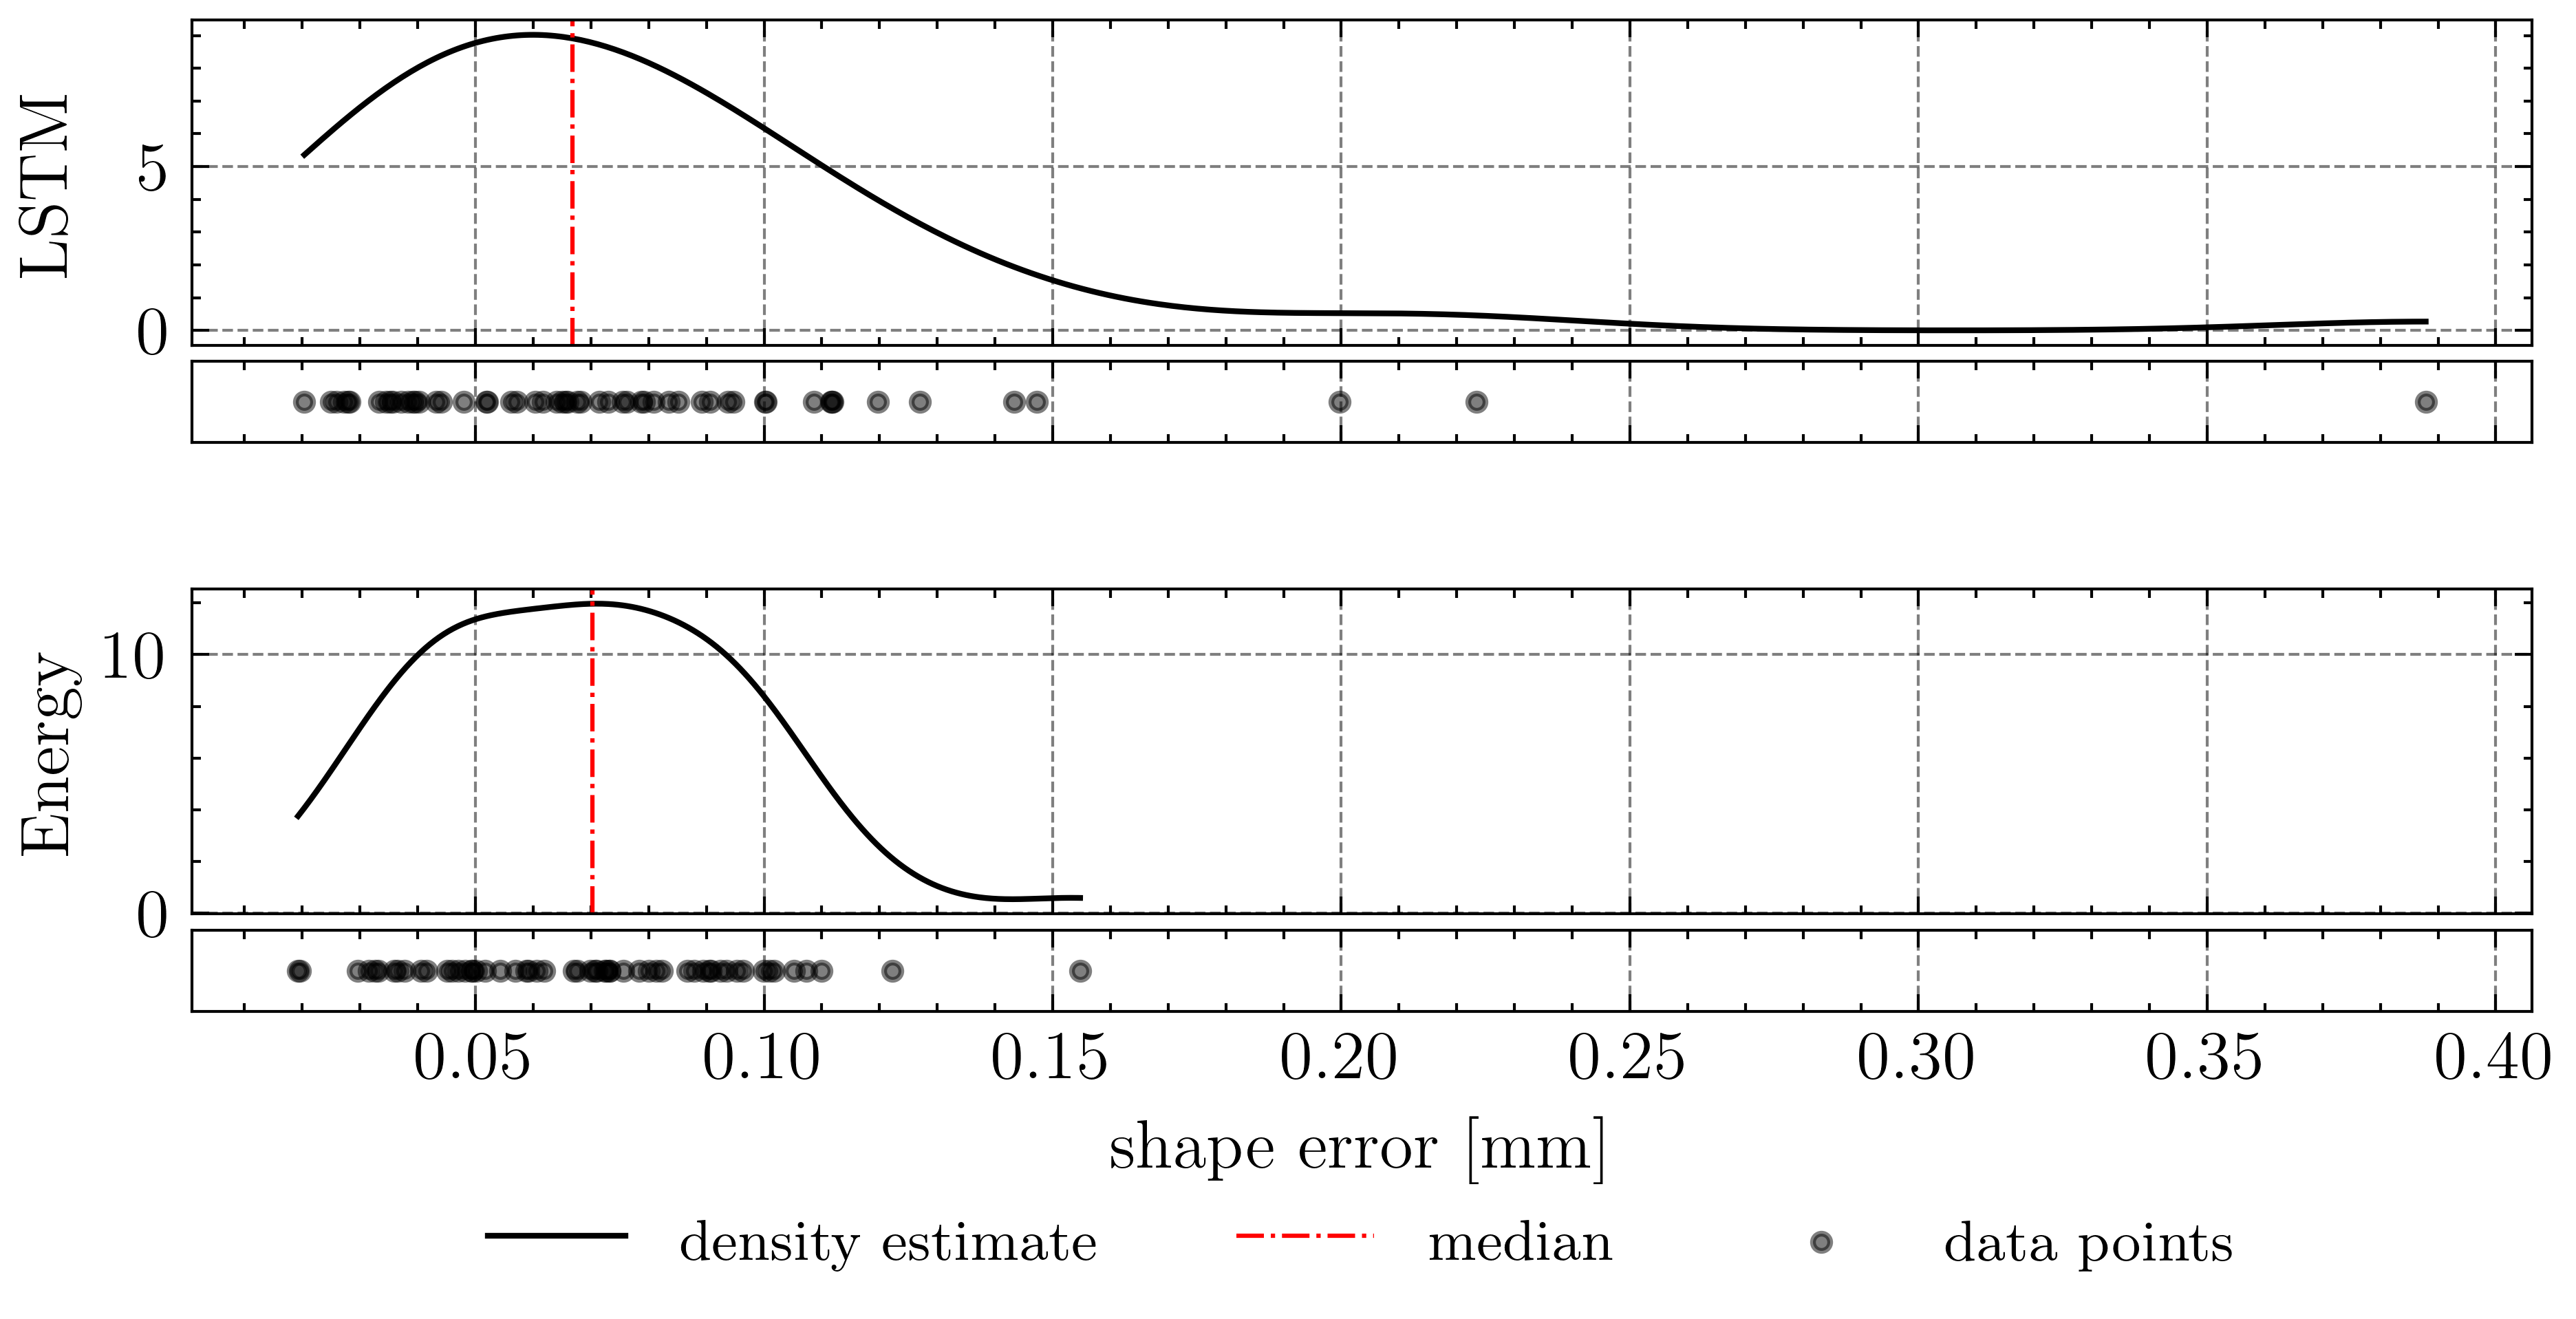

In [208]:
labels = ["Energy+measured", "LSTM+measured"]

desc = {
    "title": "",
    "x-axis": "shape error $[\mathrm{mm}]$",
    "y-axis-1": "LSTM",
    "y-axis-2": "Energy",
}
# plot_two_violions(desc, labels, [np.array(b2b_perfect_energy), np.array(modhaussdorff)])
fig = plot_two_histograms(desc, labels, [ np.array(modhaussdorff), np.array(b2b_perfect_energy),])

In [209]:
# save plot to desktop
desktop = Path("/Users/magnus/Desktop/")
folder = Path("graphics/results/")
fname = Path(f"b2b_hausdorff_{run_name}_vs_energy.pdf")
fig.savefig(desktop / folder / fname, bbox_inches='tight')

In [210]:
# comput and print out median, mean, and std for both samples
print(f"Median of b2b_perfect_energy: {np.median(b2b_perfect_energy):.4f}")
print(f"Median of modhaussdorff: {np.median(modhaussdorff):.4f}")
print(" ")

print(f"Mean of b2b_perfect_energy: {np.mean(b2b_perfect_energy):.4f}")
print(f"Mean of modhaussdorff: {np.mean(modhaussdorff):.4f}")
print(" ")

print(f"Std of b2b_perfect_energy: {np.std(b2b_perfect_energy):.4f}")
print(f"Std of modhaussdorff: {np.std(modhaussdorff):.4f}")
print(" ")

# max
print(f"Max of b2b_perfect_energy: {np.max(b2b_perfect_energy):.4f}")
print(f"Max of modhaussdorff: {np.max(modhaussdorff):.4f}")
print(" ")

#min
print(f"Min of b2b_perfect_energy: {np.min(b2b_perfect_energy):.4f}")
print(f"Min of modhaussdorff: {np.min(modhaussdorff):.4f}")



Median of b2b_perfect_energy: 0.0703
Median of modhaussdorff: 0.0668
 
Mean of b2b_perfect_energy: 0.0689
Mean of modhaussdorff: 0.0790
 
Std of b2b_perfect_energy: 0.0275
Std of modhaussdorff: 0.0582
 
Max of b2b_perfect_energy: 0.1548
Max of modhaussdorff: 0.3879
 
Min of b2b_perfect_energy: 0.0193
Min of modhaussdorff: 0.0204


In [211]:
# Generate non-normal data for the example
np.random.seed(42)
sample_1 = modhaussdorff
sample_2 = b2b_perfect_energy

# Apply Box-Cox transformation
sample_1_transformed, _ = boxcox(sample_1)
sample_2_transformed, _ = boxcox(sample_2)

# Check normality using Shapiro-Wilk test
_, p_value_1 = shapiro(sample_1_transformed)
_, p_value_2 = shapiro(sample_2_transformed)

if p_value_1 > 0.05 and p_value_2 > 0.05:
    print("Both transformed samples appear to be normally distributed.")
else:
    print("One or both transformed samples do not appear to be normally distributed.")

# Conduct the t-test for independent samples on transformed data
t_stat, p_value = ttest_ind(sample_1_transformed, sample_2_transformed)

# Choose a significance level
alpha = 0.05

# Make a decision based on the p-value
if p_value < alpha:
    print(f"Reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are statistically different.")
else:
    print(f"Fail to reject the null hypothesis (p-value = {p_value:.4f})")
    print("The means of the two transformed samples are not statistically different.")

Both transformed samples appear to be normally distributed.
Reject the null hypothesis (p-value = 0.0000)
The means of the two transformed samples are statistically different.


In [212]:
data = pd.DataFrame({
    "ids": ids.tolist(),
    "xs": xs.tolist(),
    "trues": trues.tolist(),
    "preds": preds.tolist(),
    "modhaussdorff": modhaussdorff,
    "uncertainties": uncertainties.tolist(),
})

In [213]:
data.sort_values(by="modhaussdorff", inplace=True, ascending=False)

In [214]:
data.head(4)

,ids,xs,trues,preds,modhaussdorff,uncertainties
16,Random_Ex6_09032022_20,"[4.405220031738281, 4.383469104766846, 4.36093...","[4.471887111663818, 4.453402042388916, 4.43463...","[4.405220031738281, 4.391514301300049, 4.37817...",0.387861,"[0.0, 0.10295777881856755, 0.13685488080925587..."
39,Random_Ex6_09032022_19,"[3.147965908050537, 3.1559996604919434, 3.1646...","[3.1760189533233643, 3.217210292816162, 3.2597...","[3.147965908050537, 3.1980338096618652, 3.2476...",0.223371,"[0.0, 0.4667544162065829, 0.6147877399877184, ..."
43,Random_Ex6_09032022_31,"[3.311431407928467, 3.2789337635040283, 3.2455...","[3.375751256942749, 3.362330675125122, 3.35346...","[3.311431646347046, 3.307833671569824, 3.30434...",0.199649,"[0.0, 0.056990186647224016, 0.0737913099692335..."
19,Random_Ex6_09032022_49,"[2.2455551624298096, 2.222524642944336, 2.2001...","[2.2896511554718018, 2.324838161468506, 2.3553...","[2.2455556392669678, 2.263416051864624, 2.2812...",0.147236,"[0.0, 0.07942033201651036, 0.10449361684747736..."


In [215]:
# get row i
data.iloc[0]

ids                                         Random_Ex6_09032022_20
xs               [4.405220031738281, 4.383469104766846, 4.36093...
trues            [4.471887111663818, 4.453402042388916, 4.43463...
preds            [4.405220031738281, 4.391514301300049, 4.37817...
modhaussdorff                                             0.387861
uncertainties    [0.0, 0.10295777881856755, 0.13685488080925587...
Name: 16, dtype: object

In [281]:
def plot_sample(data, title=""): 
    cm = 1 / 2.54
    
    pred_mean = np.array(data["preds"])
    pred_std = np.array(data["uncertainties"])
    trgt = np.array(data["trues"])
    inpt = np.array(data["xs"])
    id_ = data["ids"]
    error = np.abs(pred_mean - trgt)
    
    x = np.arange(0, 90 / 10, 0.1)
    
    fig, (ax, ax2) = plt.subplots(2, figsize=( 10 * cm, 9*cm), dpi=600, sharex=True, gridspec_kw={"height_ratios": [6, 2]})
    ax.plot(x, pred_mean, color="blue", label="pred_mean")
    # plot std around mean
    ax.fill_between(
        x,
        pred_mean - pred_std,
        pred_mean + pred_std,
        color="red",
        alpha=0.2,
        label="uncertainty [mm]",
    )
    
    ax.plot(x, trgt, color="green", label="target (after)", ls="-")
    ax.plot(x, inpt, color="black", label="input (before)", ls="-")
    ax.set_ylabel("z [mm]")
    
    ax.set_ylim(-1, 5.2)
    # ax.axis("equal")
    ax.set_title(title)
    ax.set_yticks([-1, 0, 1, 2, 3, 4, 5])

    ax2.plot(x, pred_std, color="red", label="uncertainty [mm]", ls="--")
    ax2.plot(x, error, color="orange", label="error [mm]", ls="--")
    ax2.set_ylim(0, np.max([np.max(error), np.max(pred_std)]) + 0.02)
    ax2.set_xlabel("x [mm]")

    fig.align_ylabels()
    
    # place legend of all axis combined in one below ax4
    # lines, labels = ax.get_legend_handles_labels()
    # li4, la4 = ax2.get_legend_handles_labels()
    # lines.extend(li4)
    # labels.extend(la4)
    # ax2.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=2)
    # plt.setp(ax2.get_legend().get_texts(), fontsize='small')
    # ax2.get_legend().get_frame().set_linewidth(0.0)  
    # return legend and dont plit it    
    return fig


1.8379557169726308
6.235911758383381
1.562626198613784


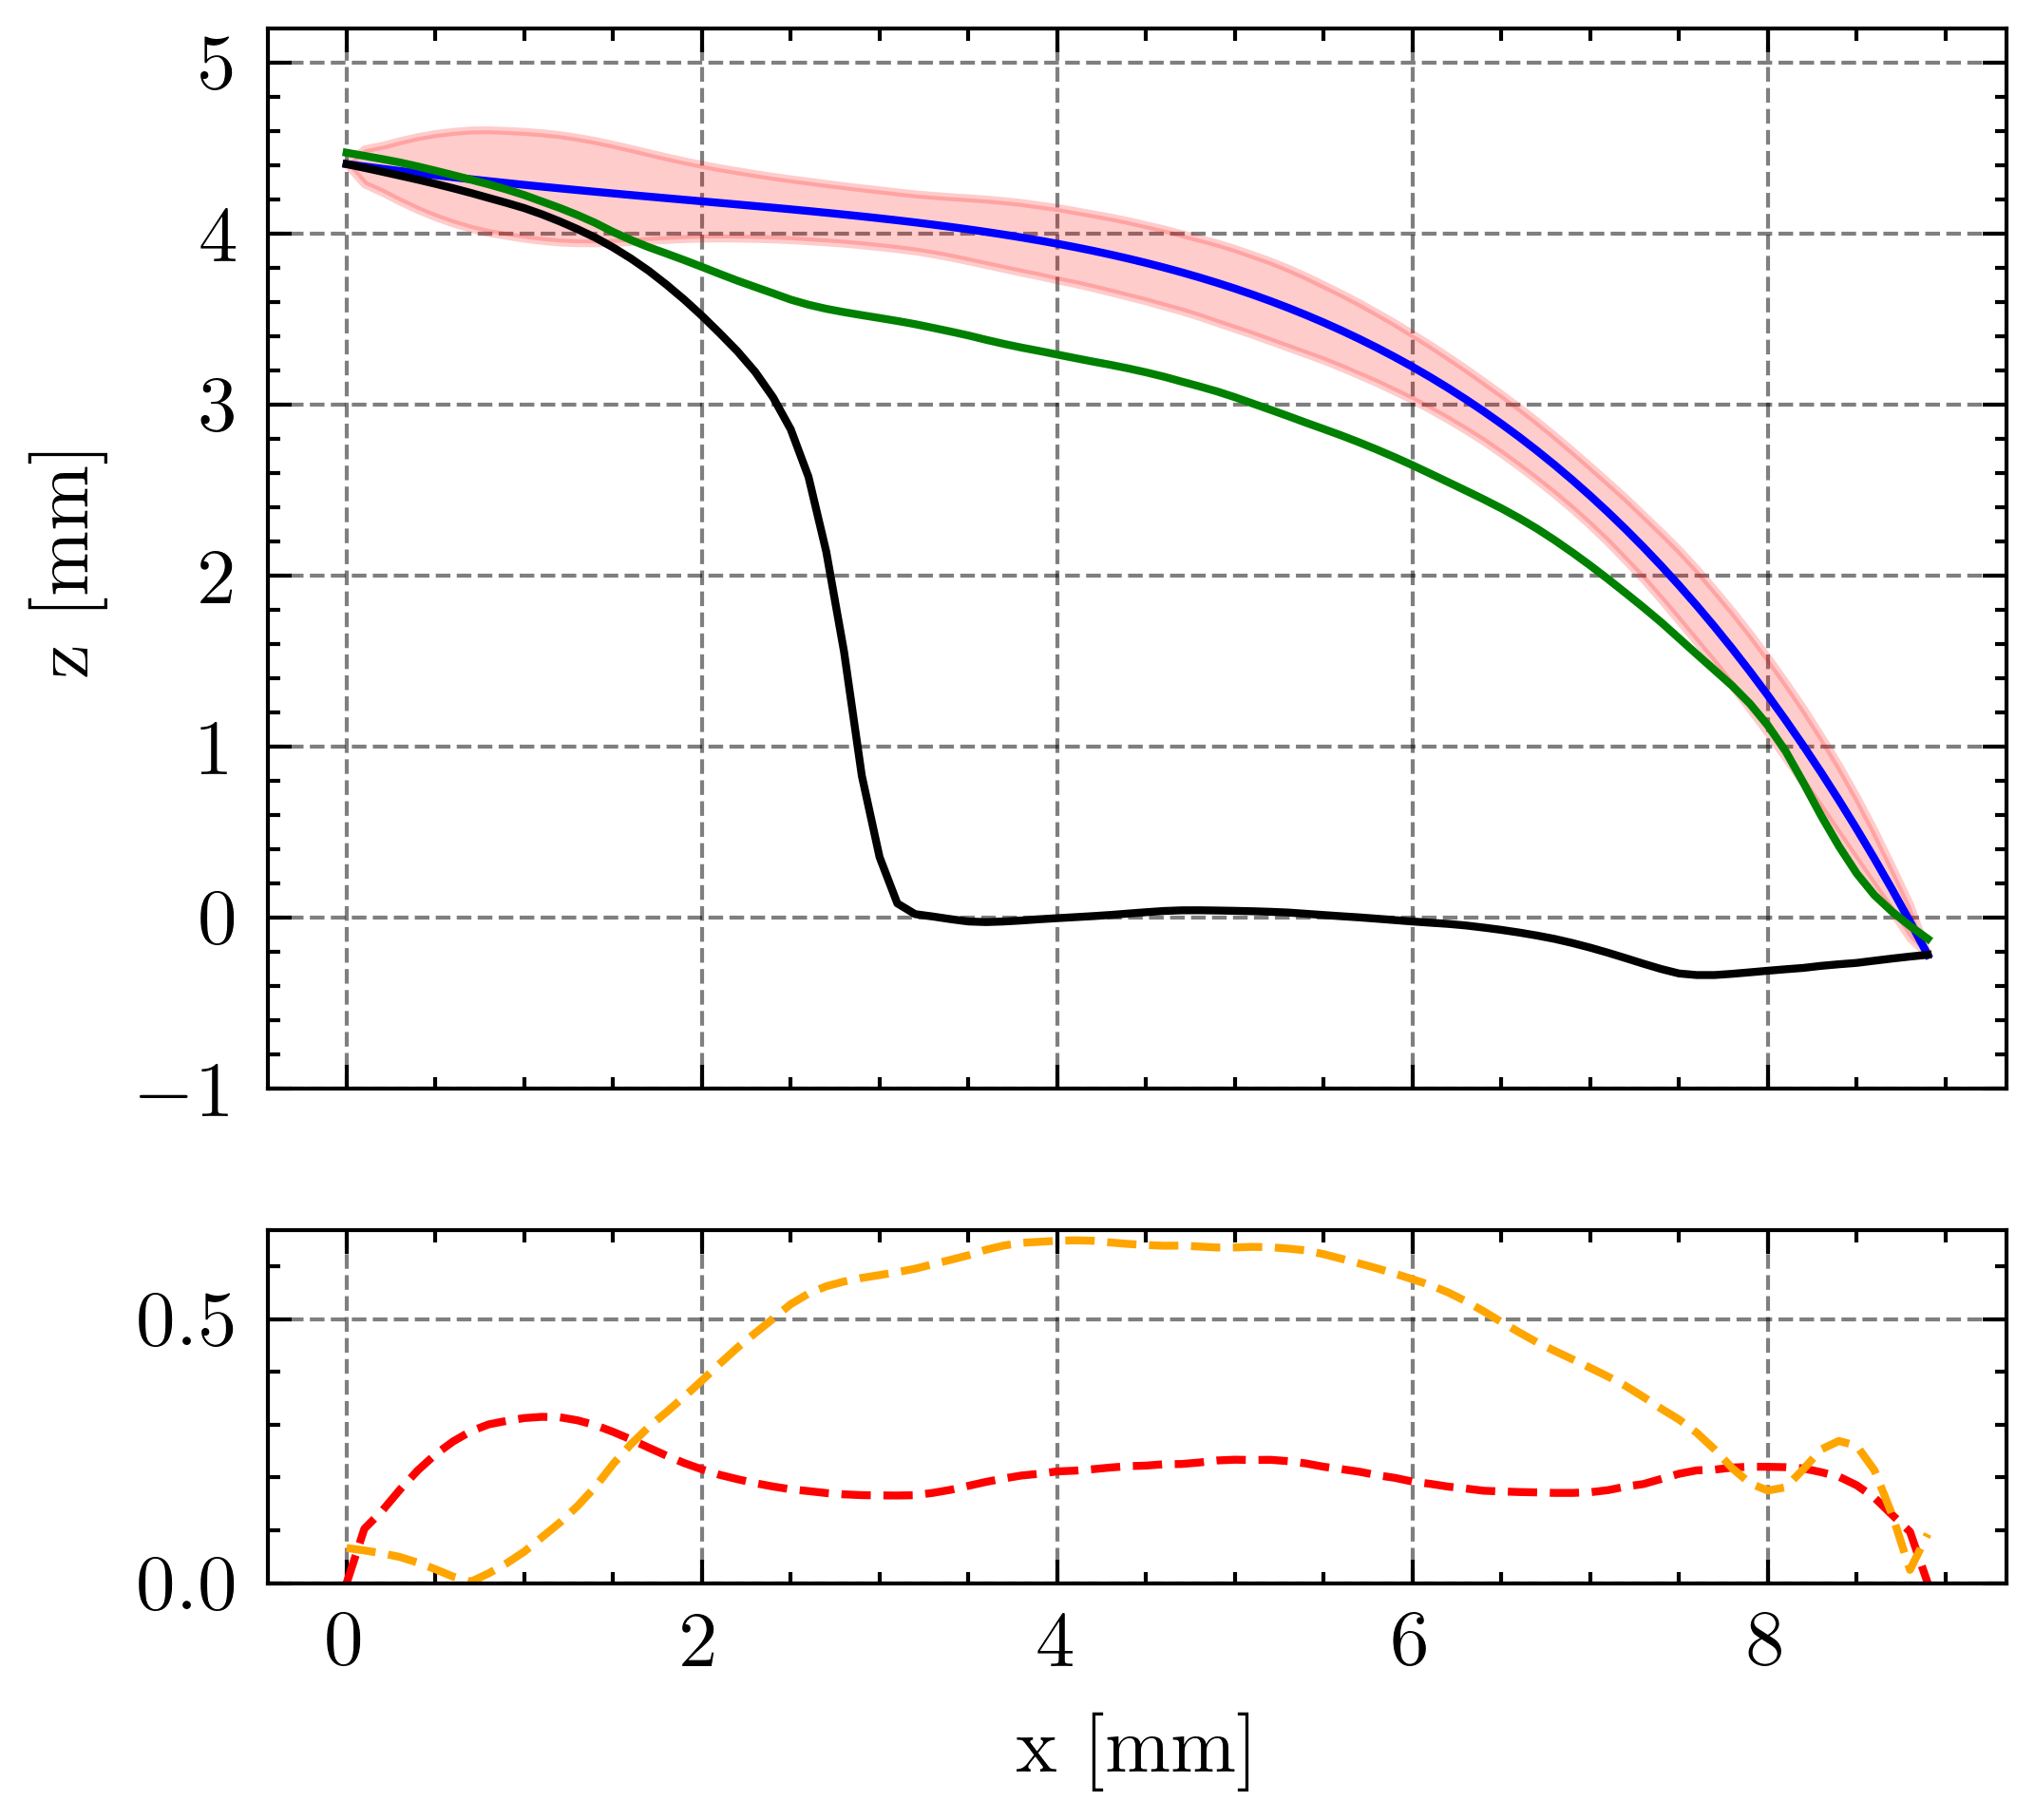

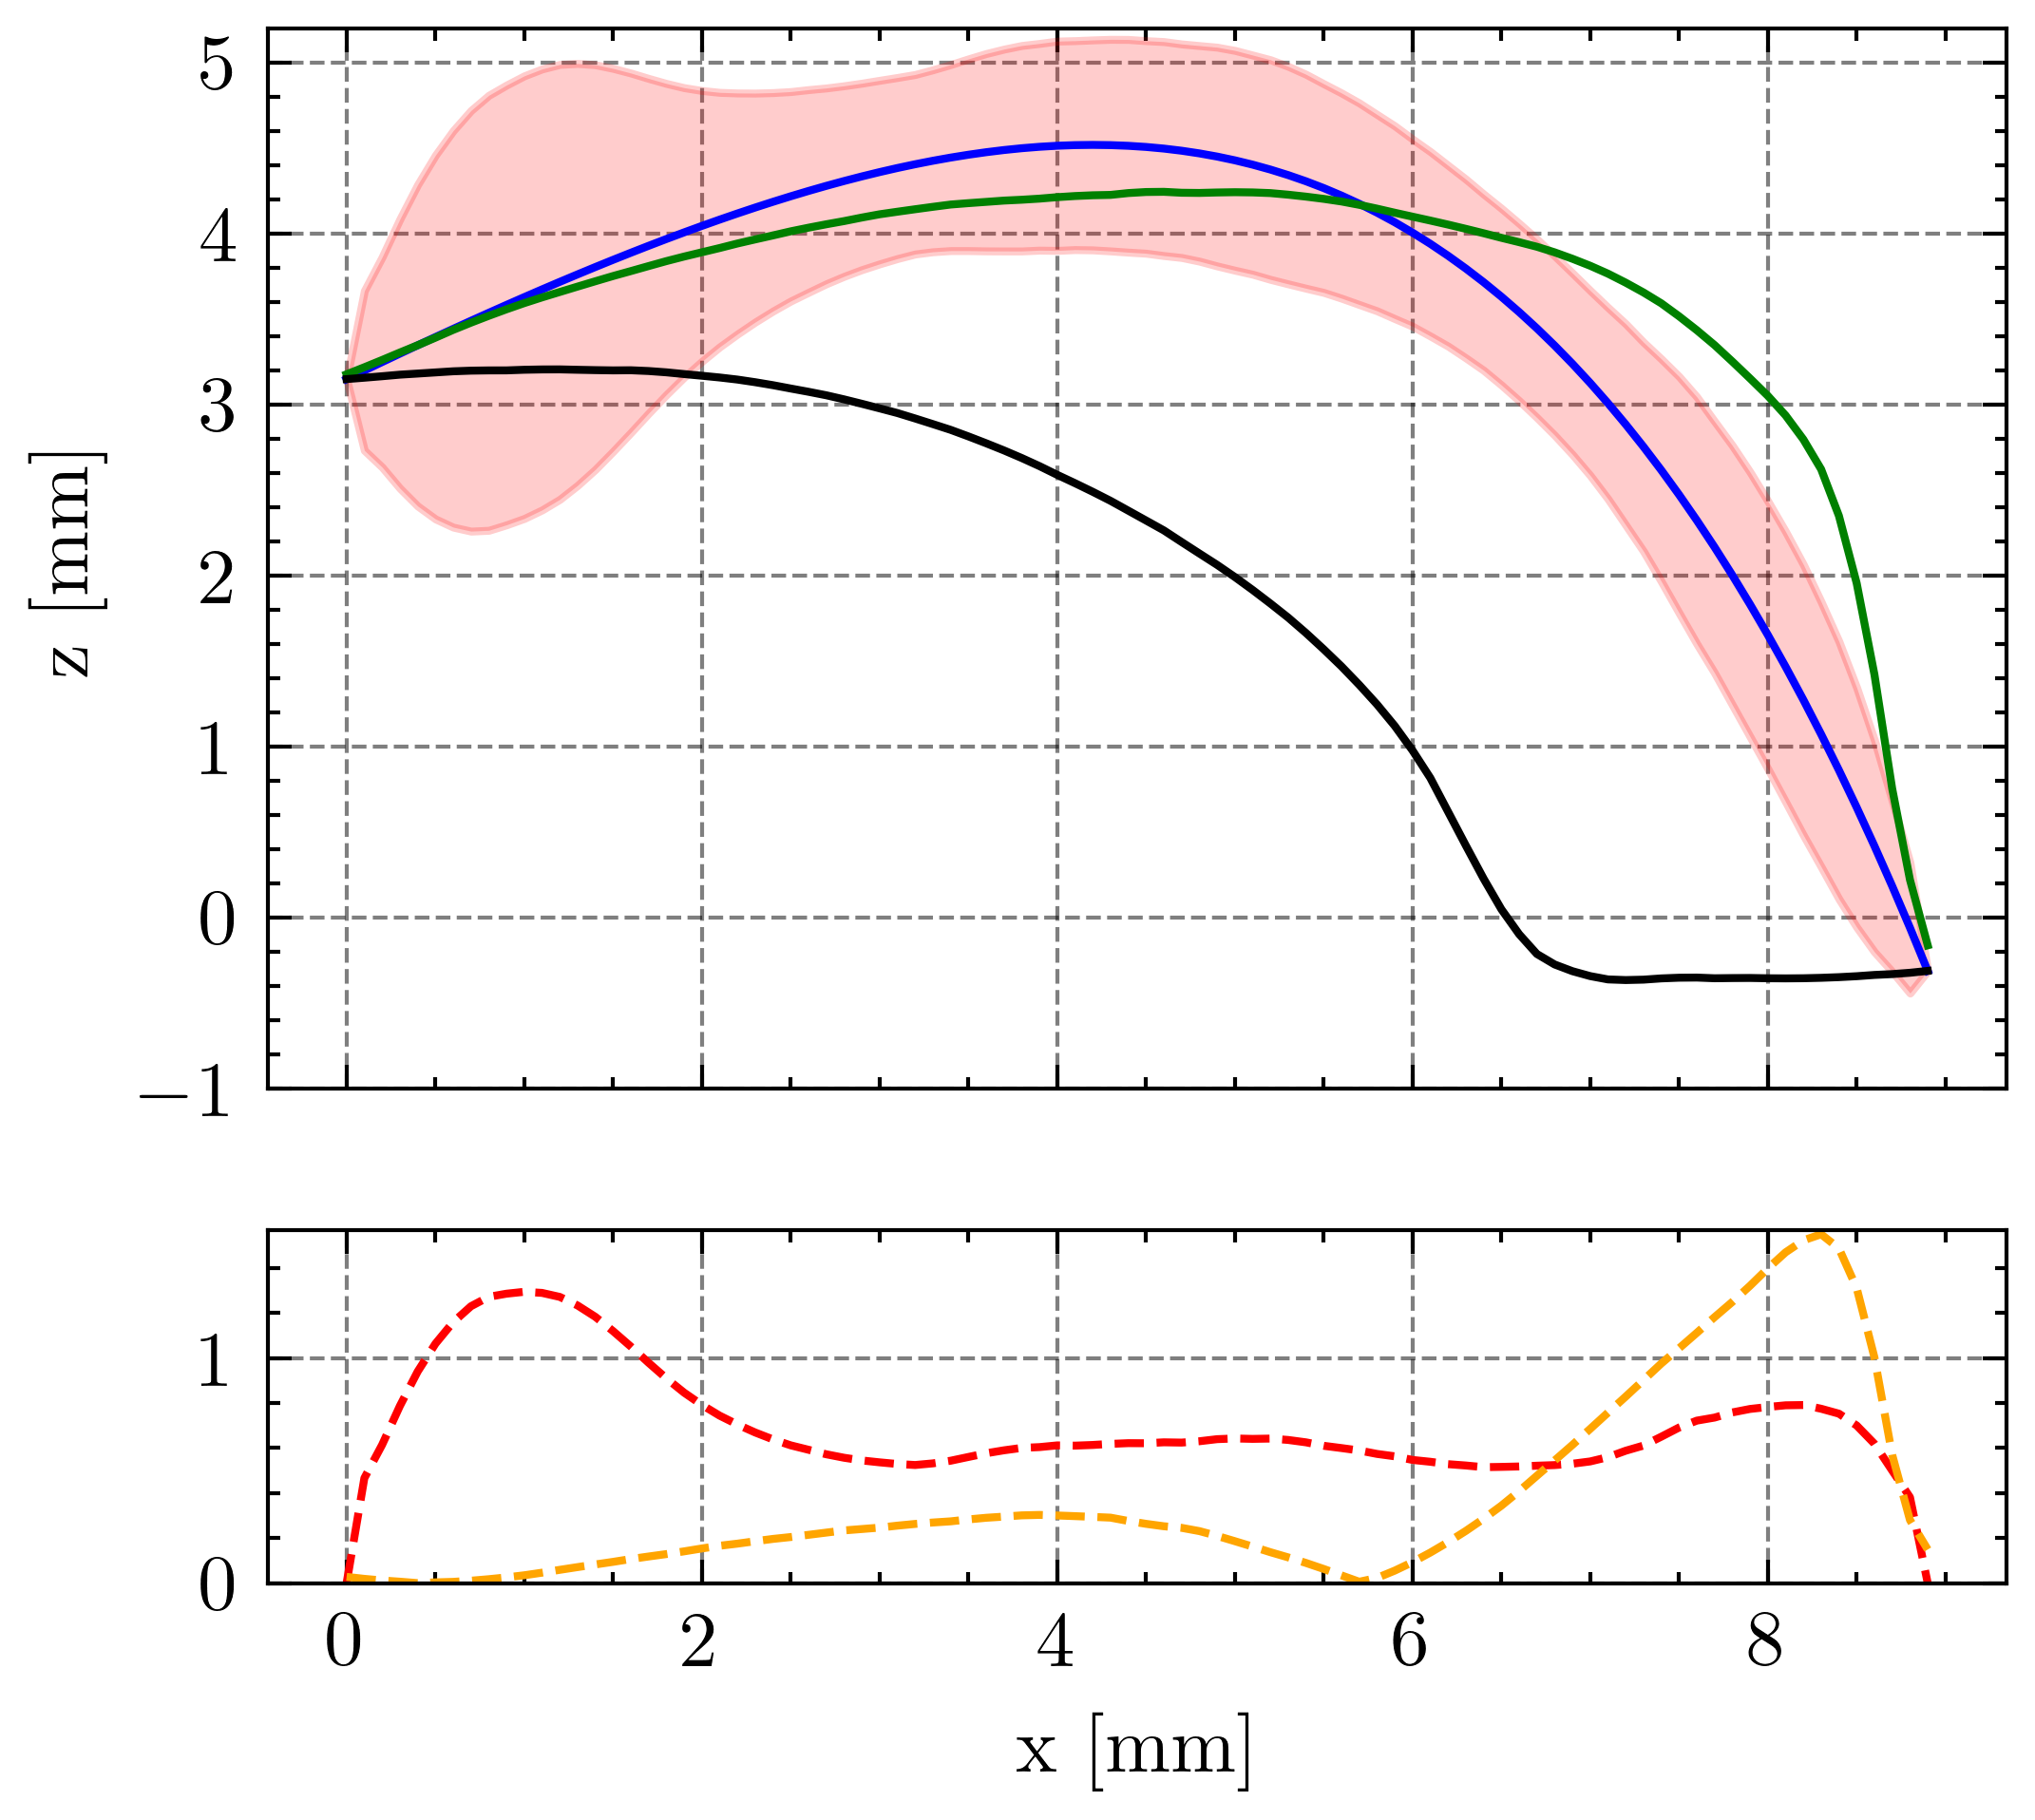

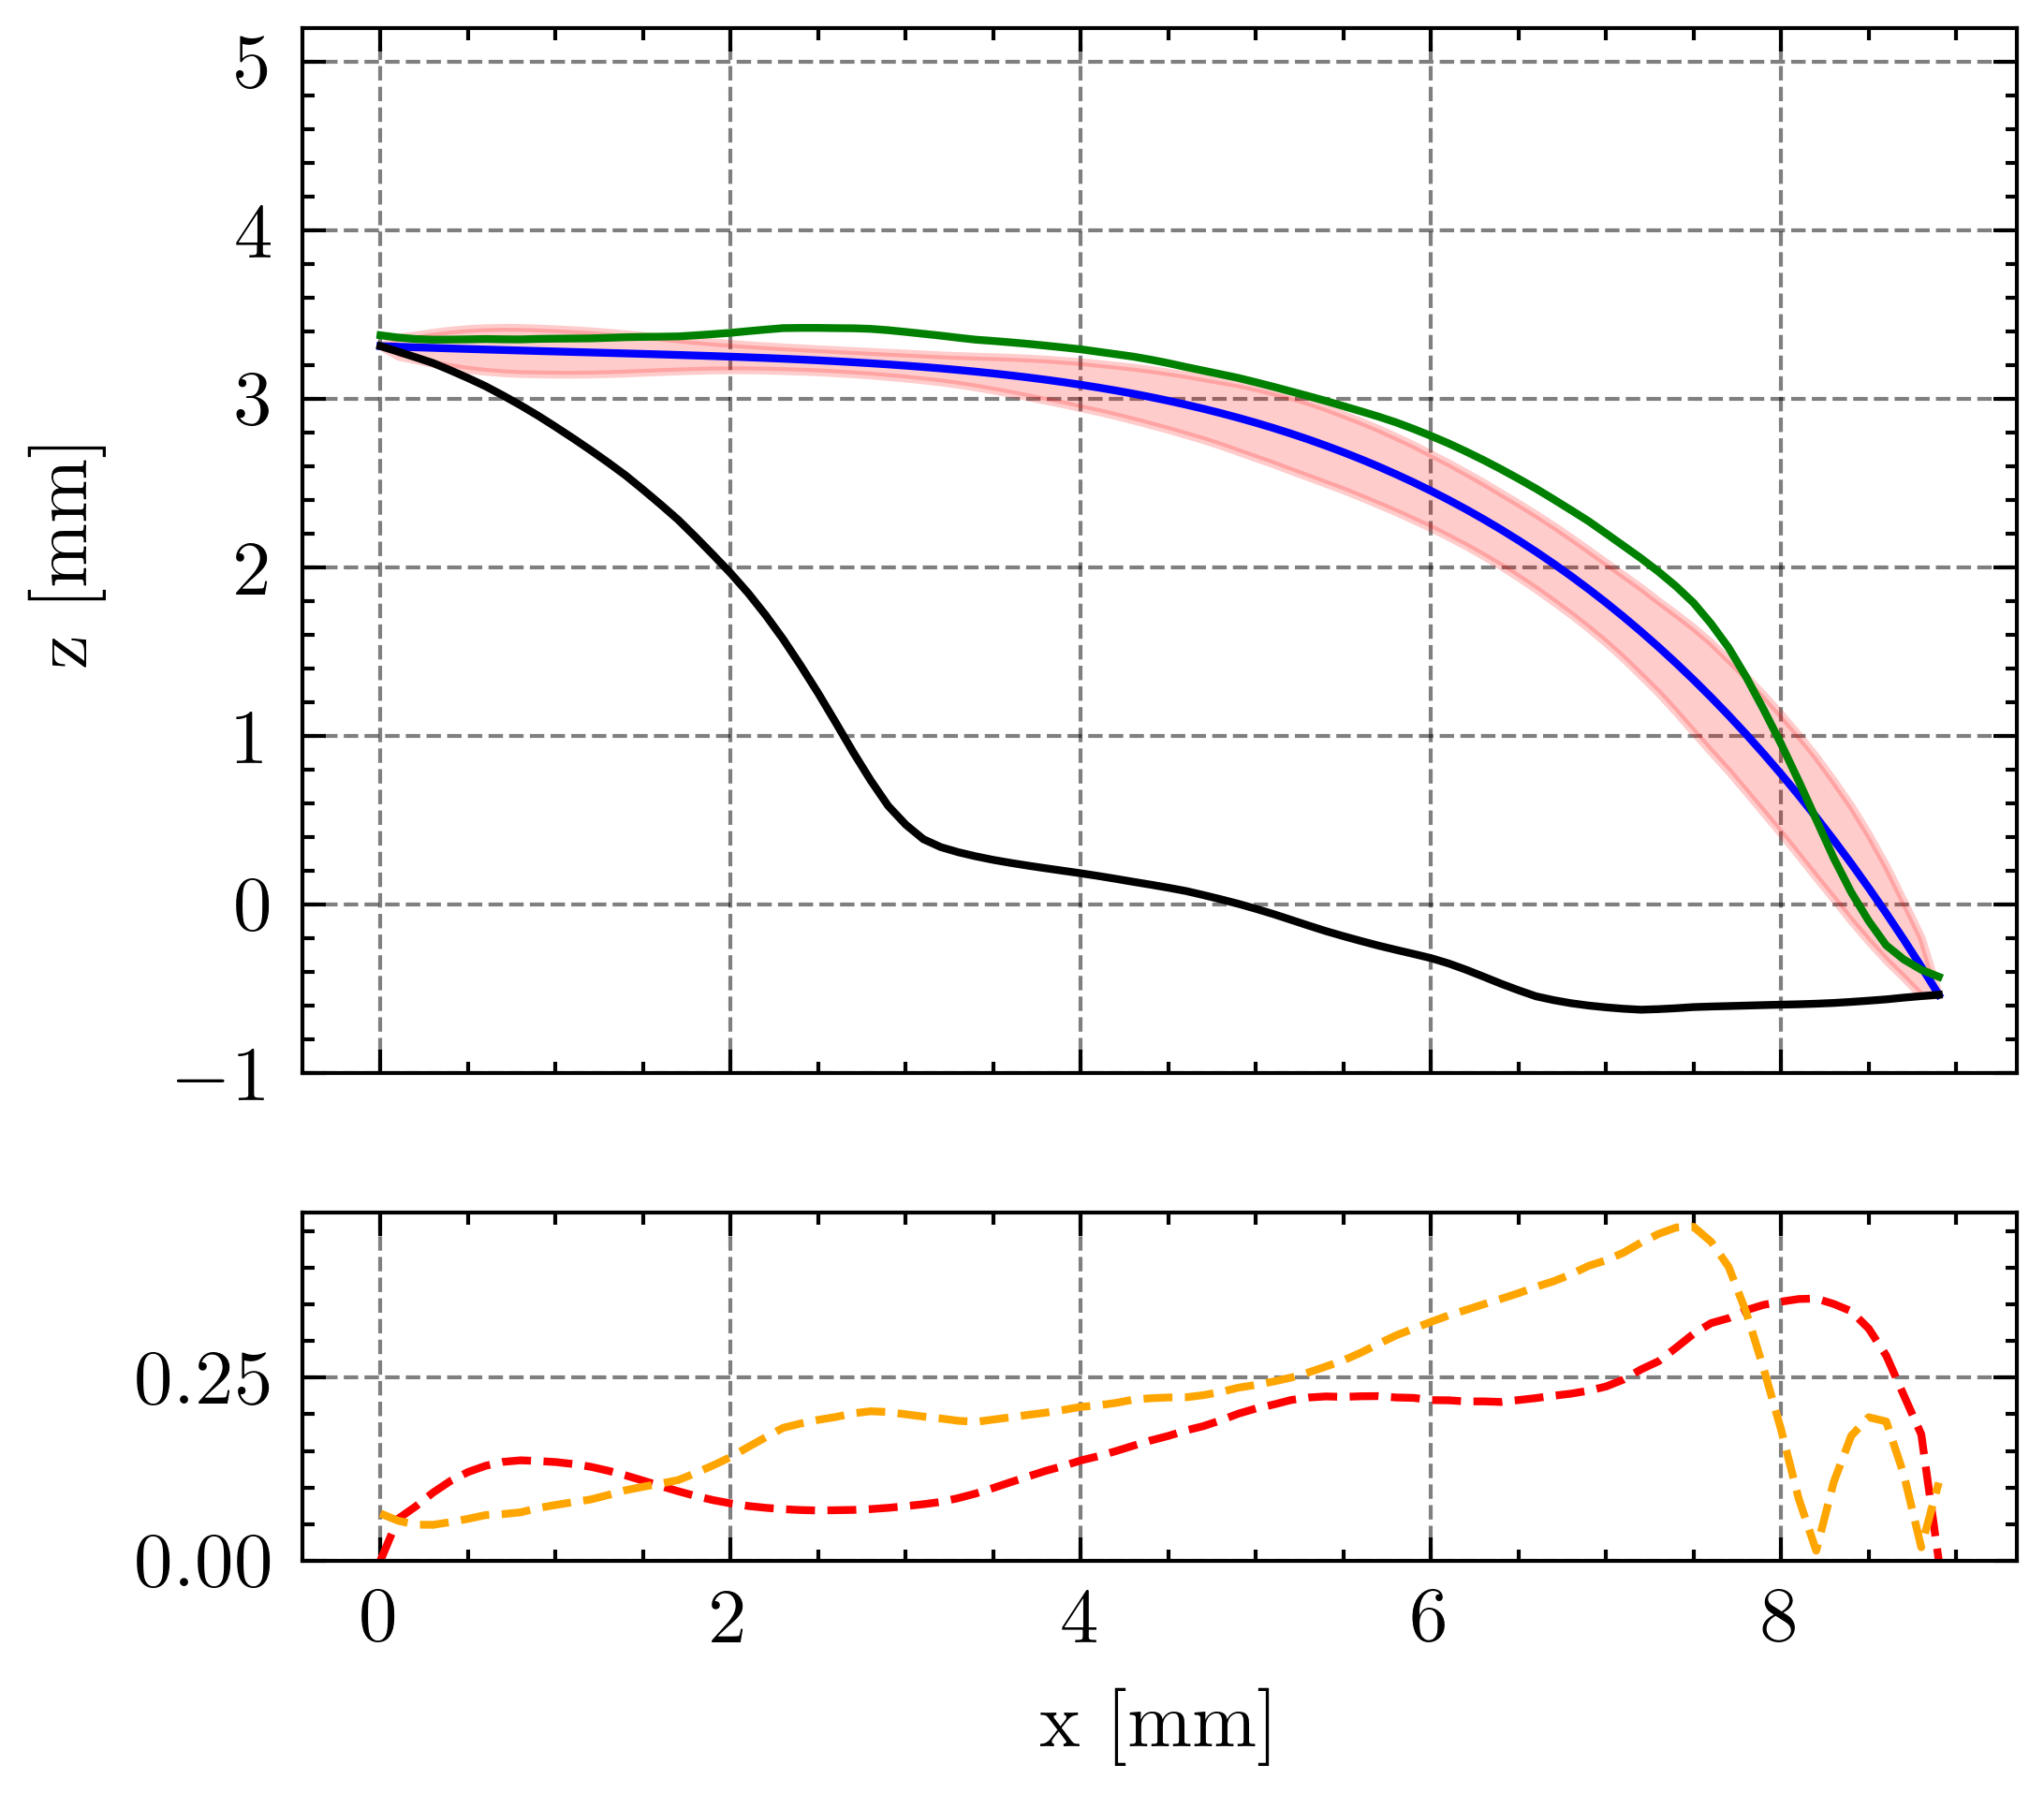

In [283]:
desktop = Path("/Users/magnus/Desktop/")
folder = Path("graphics/results/samples")

for i in range(3):
    fig = plot_sample(data.iloc[i])
    score = np.array(data.iloc[i]["uncertainties"]).sum() * 0.1
    print(score)
    fname = Path(f"sample_{data.iloc[i]['ids']}_hausdorff-{data.iloc[i]['modhaussdorff']:.3f}_score-{score:.3f}.pdf")
    fig.savefig(desktop / folder / fname, bbox_inches='tight')
    

1.562626198613784


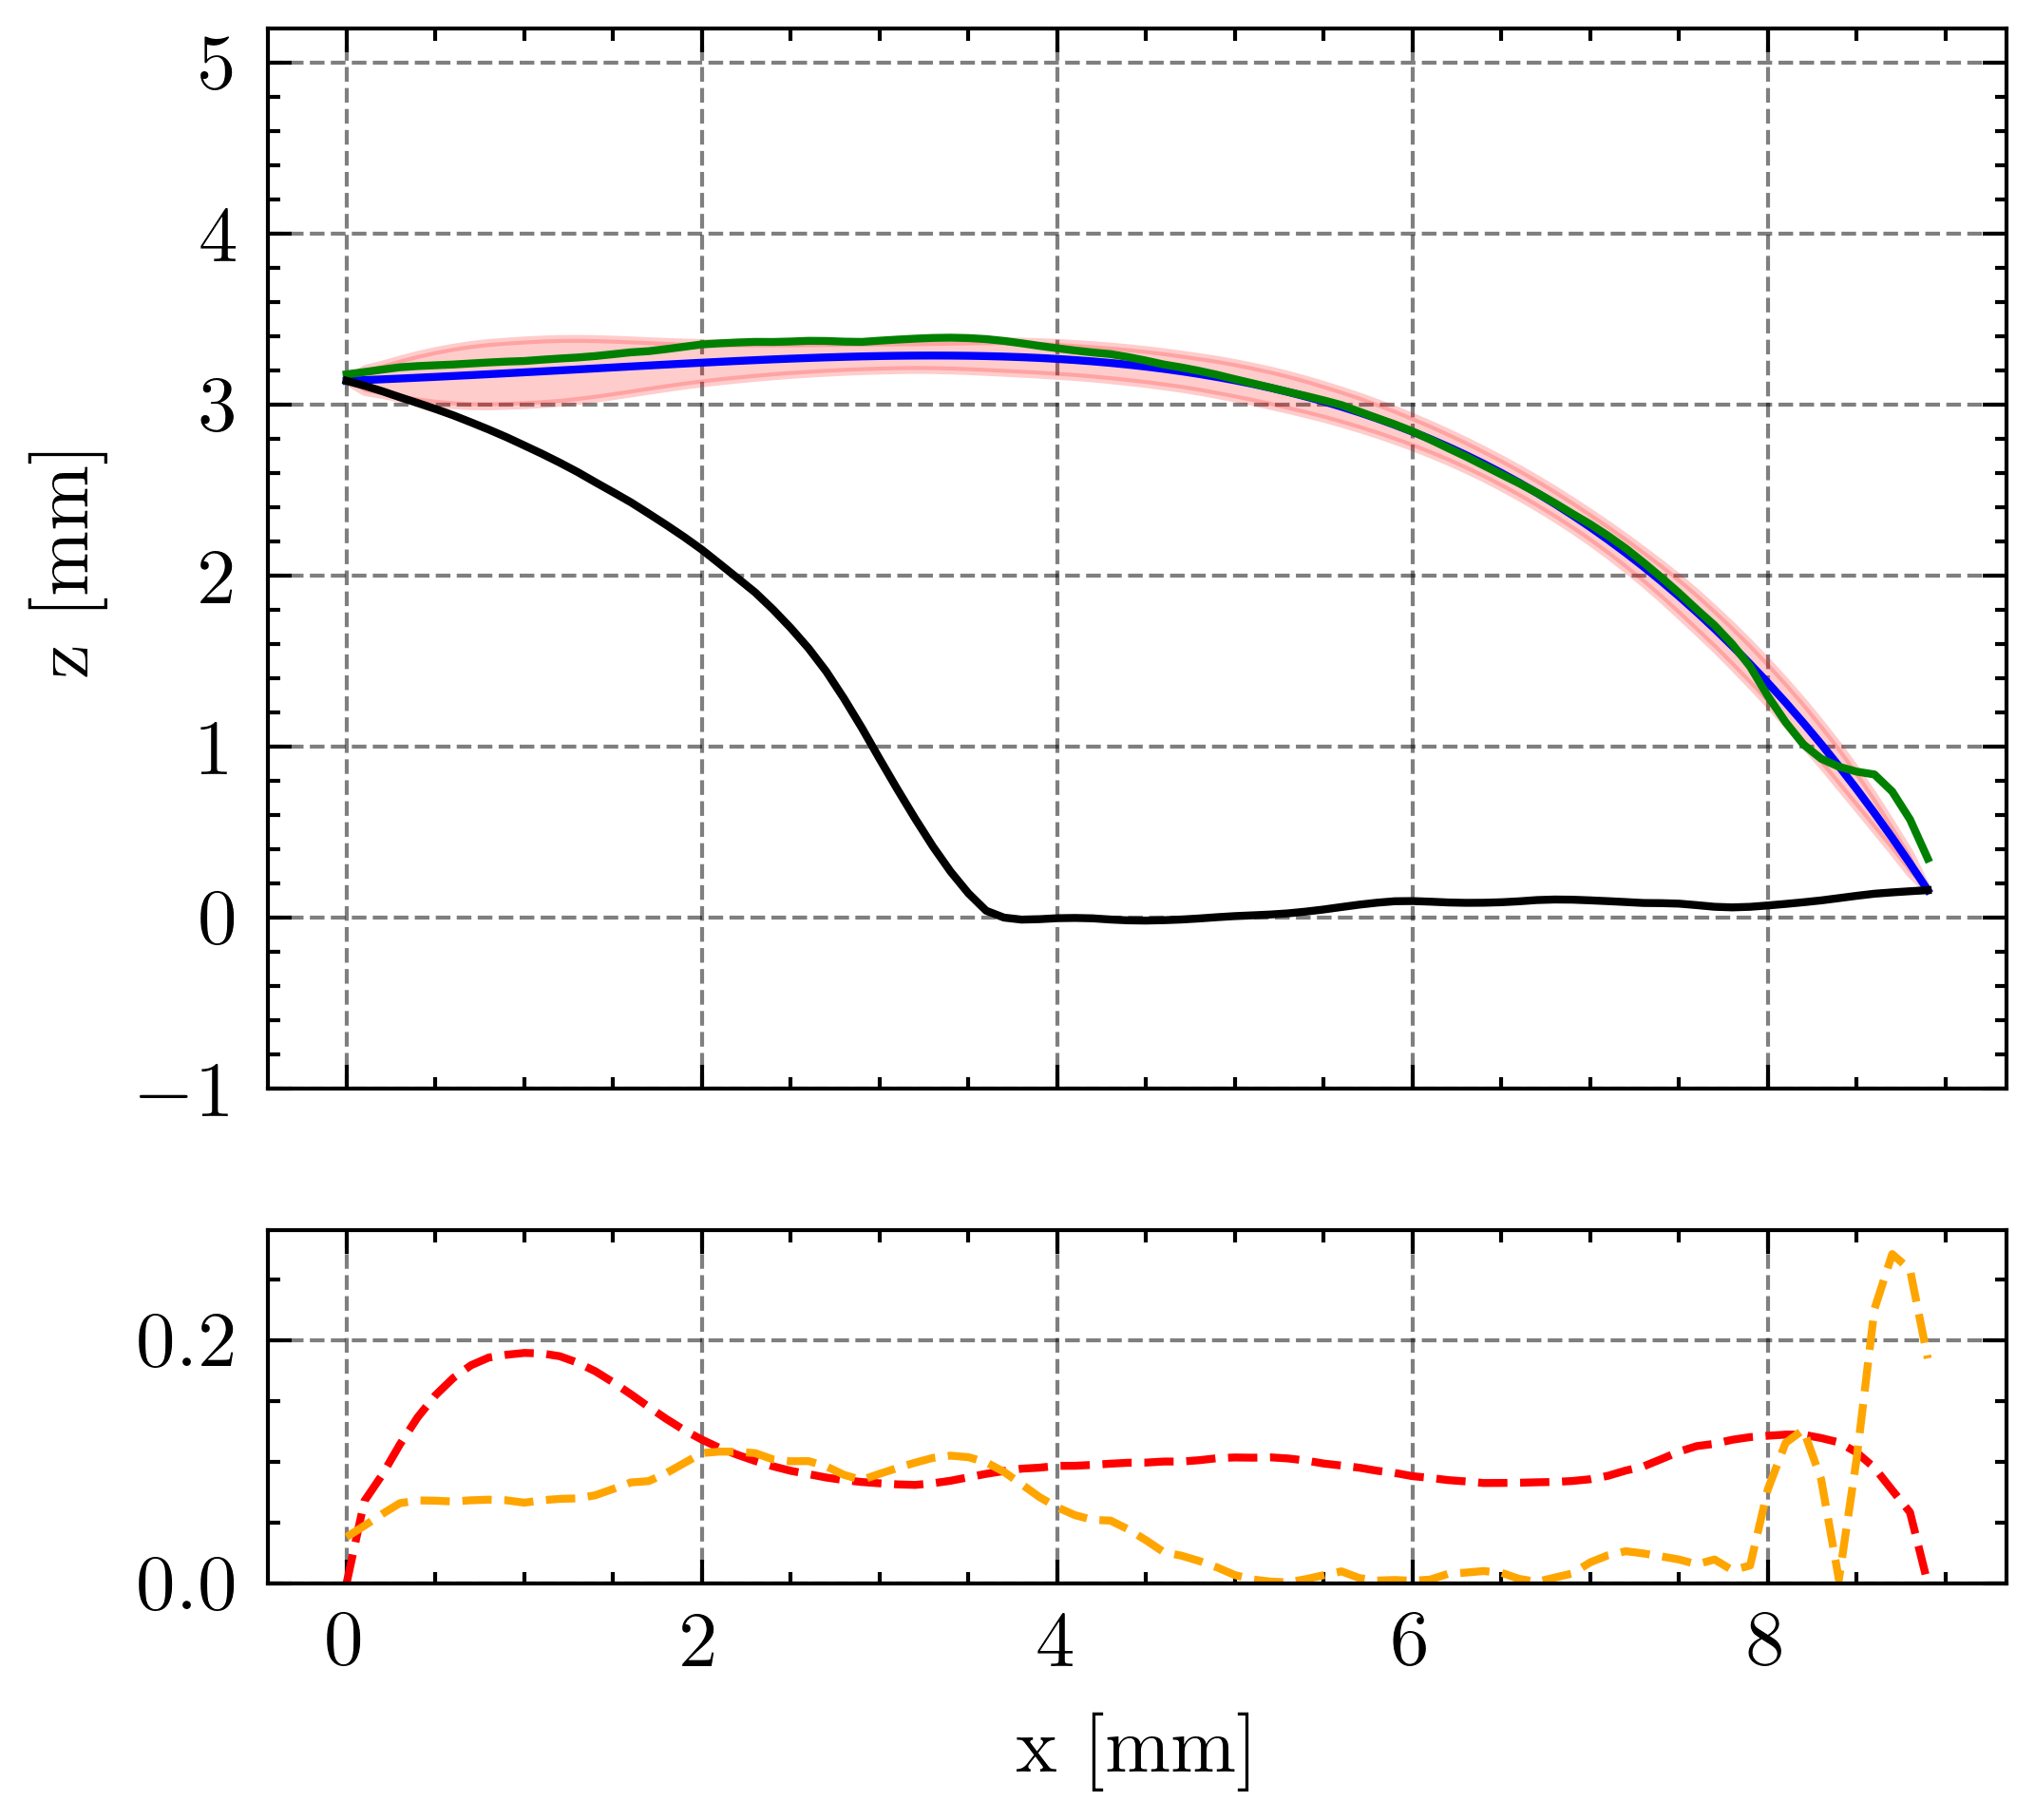

In [286]:
fig = plot_sample(data.iloc[28])
score = np.array(data.iloc[i]["uncertainties"]).sum() * 0.1
print(score)
fname = Path(f"sample_{data.iloc[i]['ids']}_hausdorff-{data.iloc[i]['modhaussdorff']:.3f}(median).pdf")
fig.savefig(desktop / folder / fname, bbox_inches='tight')

In [ ]:
for i in range(56):
    fig = plot_sample(data.iloc[i])
    score = np.array(data.iloc[i]["uncertainties"]).sum() * 0.1
    print(score)
    fname = Path(f"sample_{data.iloc[i]['ids']}({i+1})_hausdorff-{data.iloc[i]['modhaussdorff']:.3f}_score-{score:.3f}.pdf")
    fig.savefig(desktop / folder / fname, bbox_inches='tight')

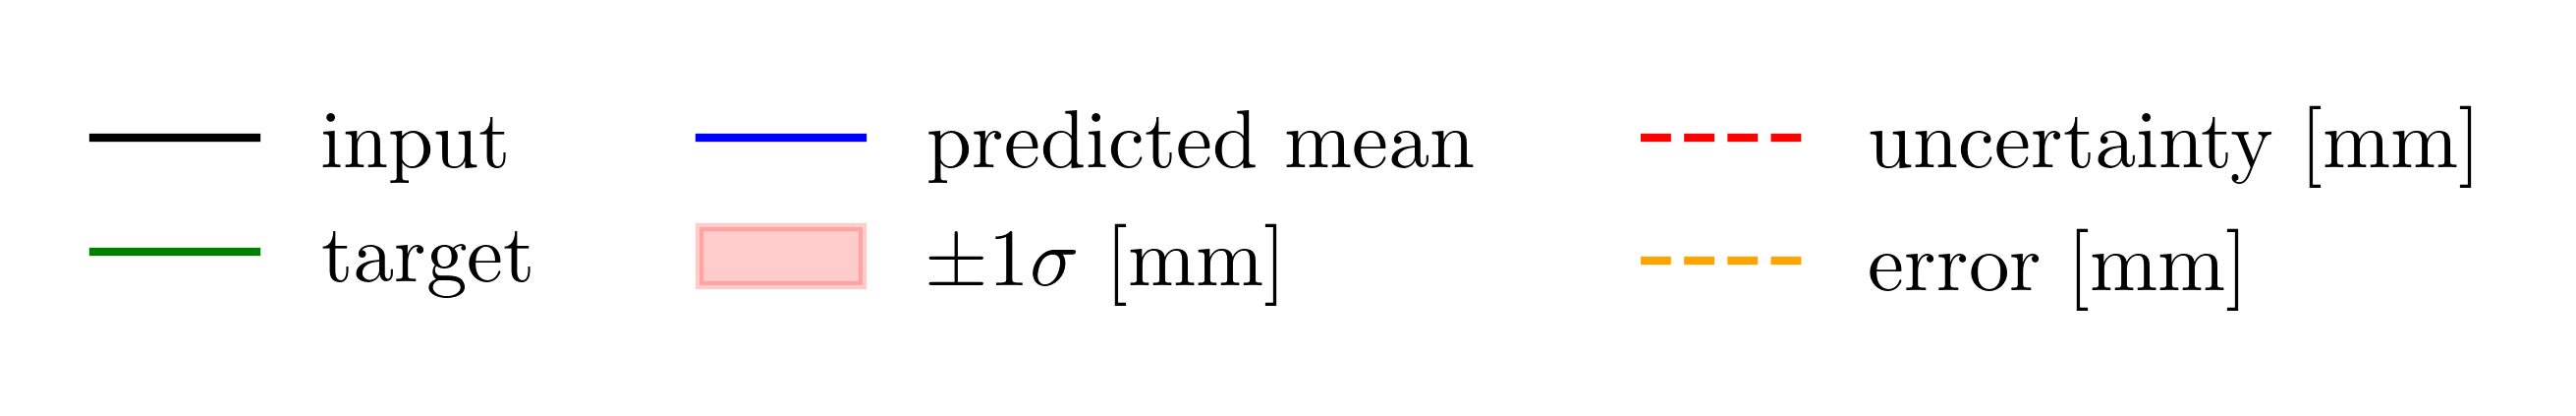

In [275]:
# for i in range(1):
#     fig, lines = plot_sample(data.iloc[i])
    
# Extract the legend as a separate figure
cm= 1/2.54
legend_fig, legend_ax = plt.subplots(figsize=(14*cm, 2*cm))
# legend_ax = legend_fig.add_subplot(111)
# legend_ax.axis('off')
legend_ax.plot([], color="black", ls="-", label="input")
legend_ax.plot([], color="green", ls="-", label="target")
legend_ax.plot([], color="blue", ls="-", label="predicted mean")
legend_ax.fill_between([], [], [], color="red", alpha=0.2, label="$\pm 1 \sigma$ [mm]")
legend_ax.plot([], color="red", ls="--", label="uncertainty [mm]")
legend_ax.plot([], color="orange", ls="--", label="error [mm]")
legend_ax.axis('off')
legend_ax.legend(loc='center', ncol=3)
legend_ax.get_legend().get_frame().set_linewidth(0.0)

# save fig
desktop = Path("/Users/magnus/Desktop/")
folder = Path("graphics/results/samples")
fname = Path(f"sample_plots_legend.pdf")
legend_fig.savefig(desktop / folder / fname, bbox_inches='tight')

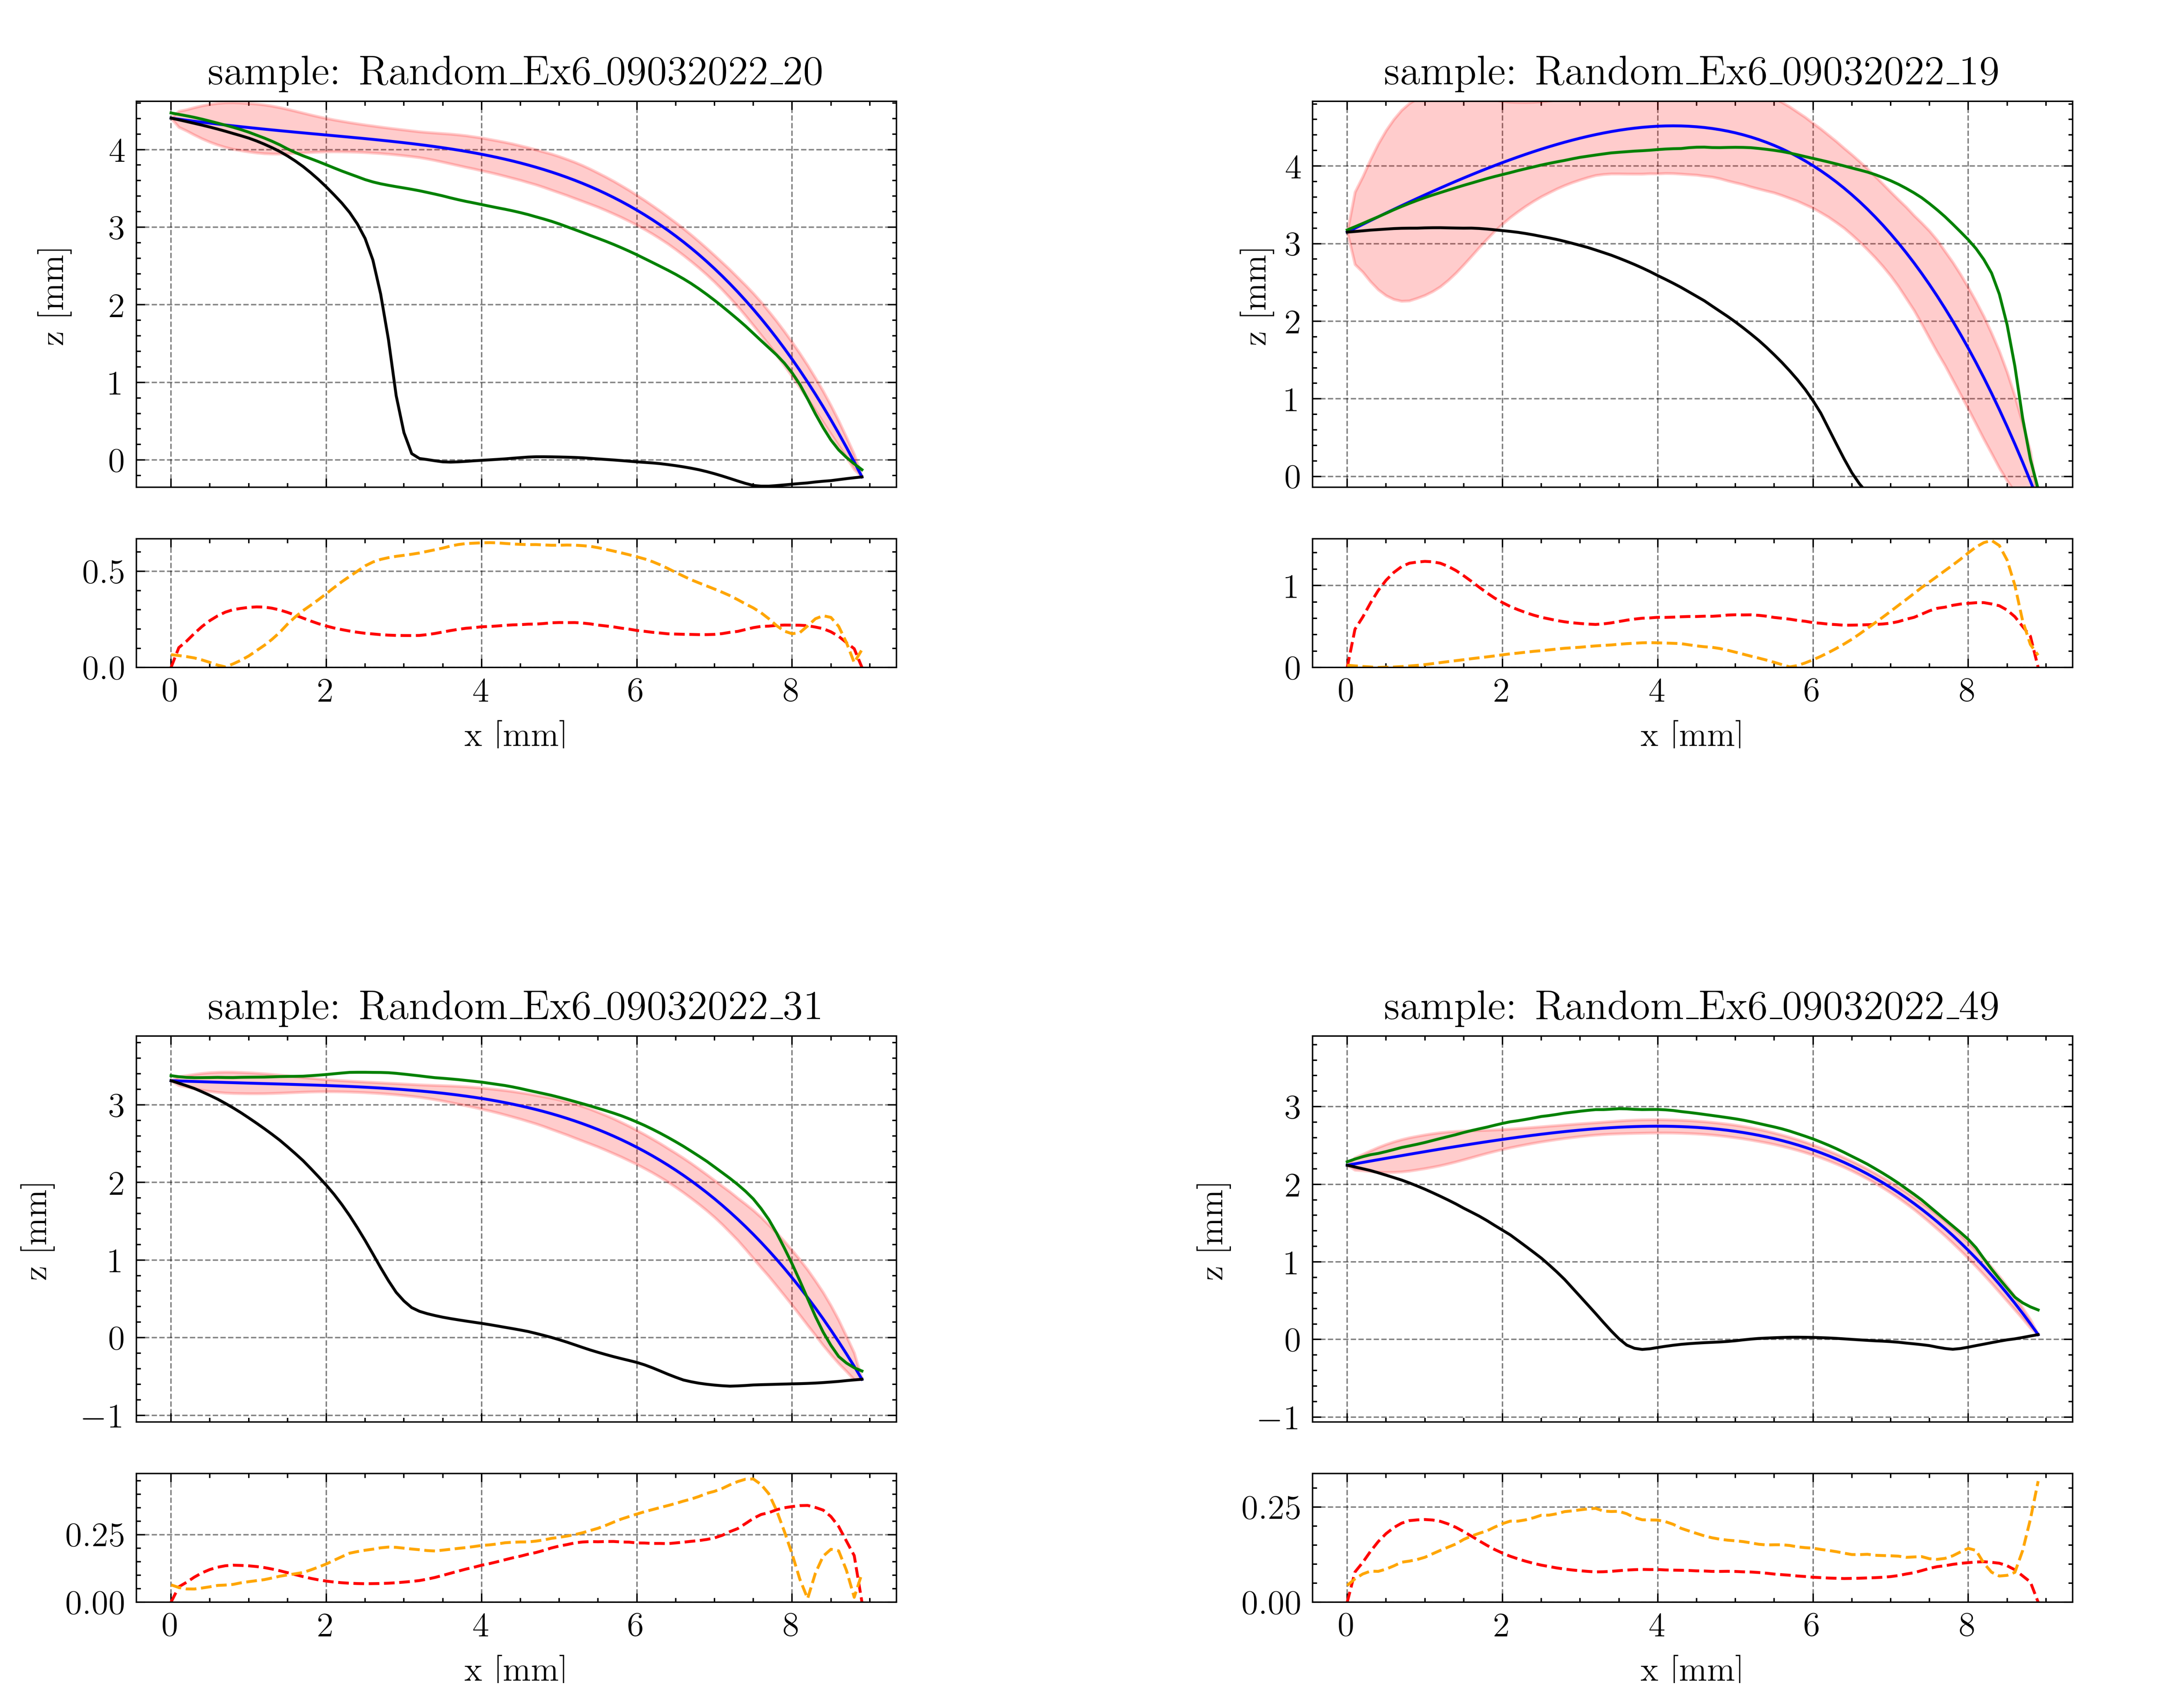

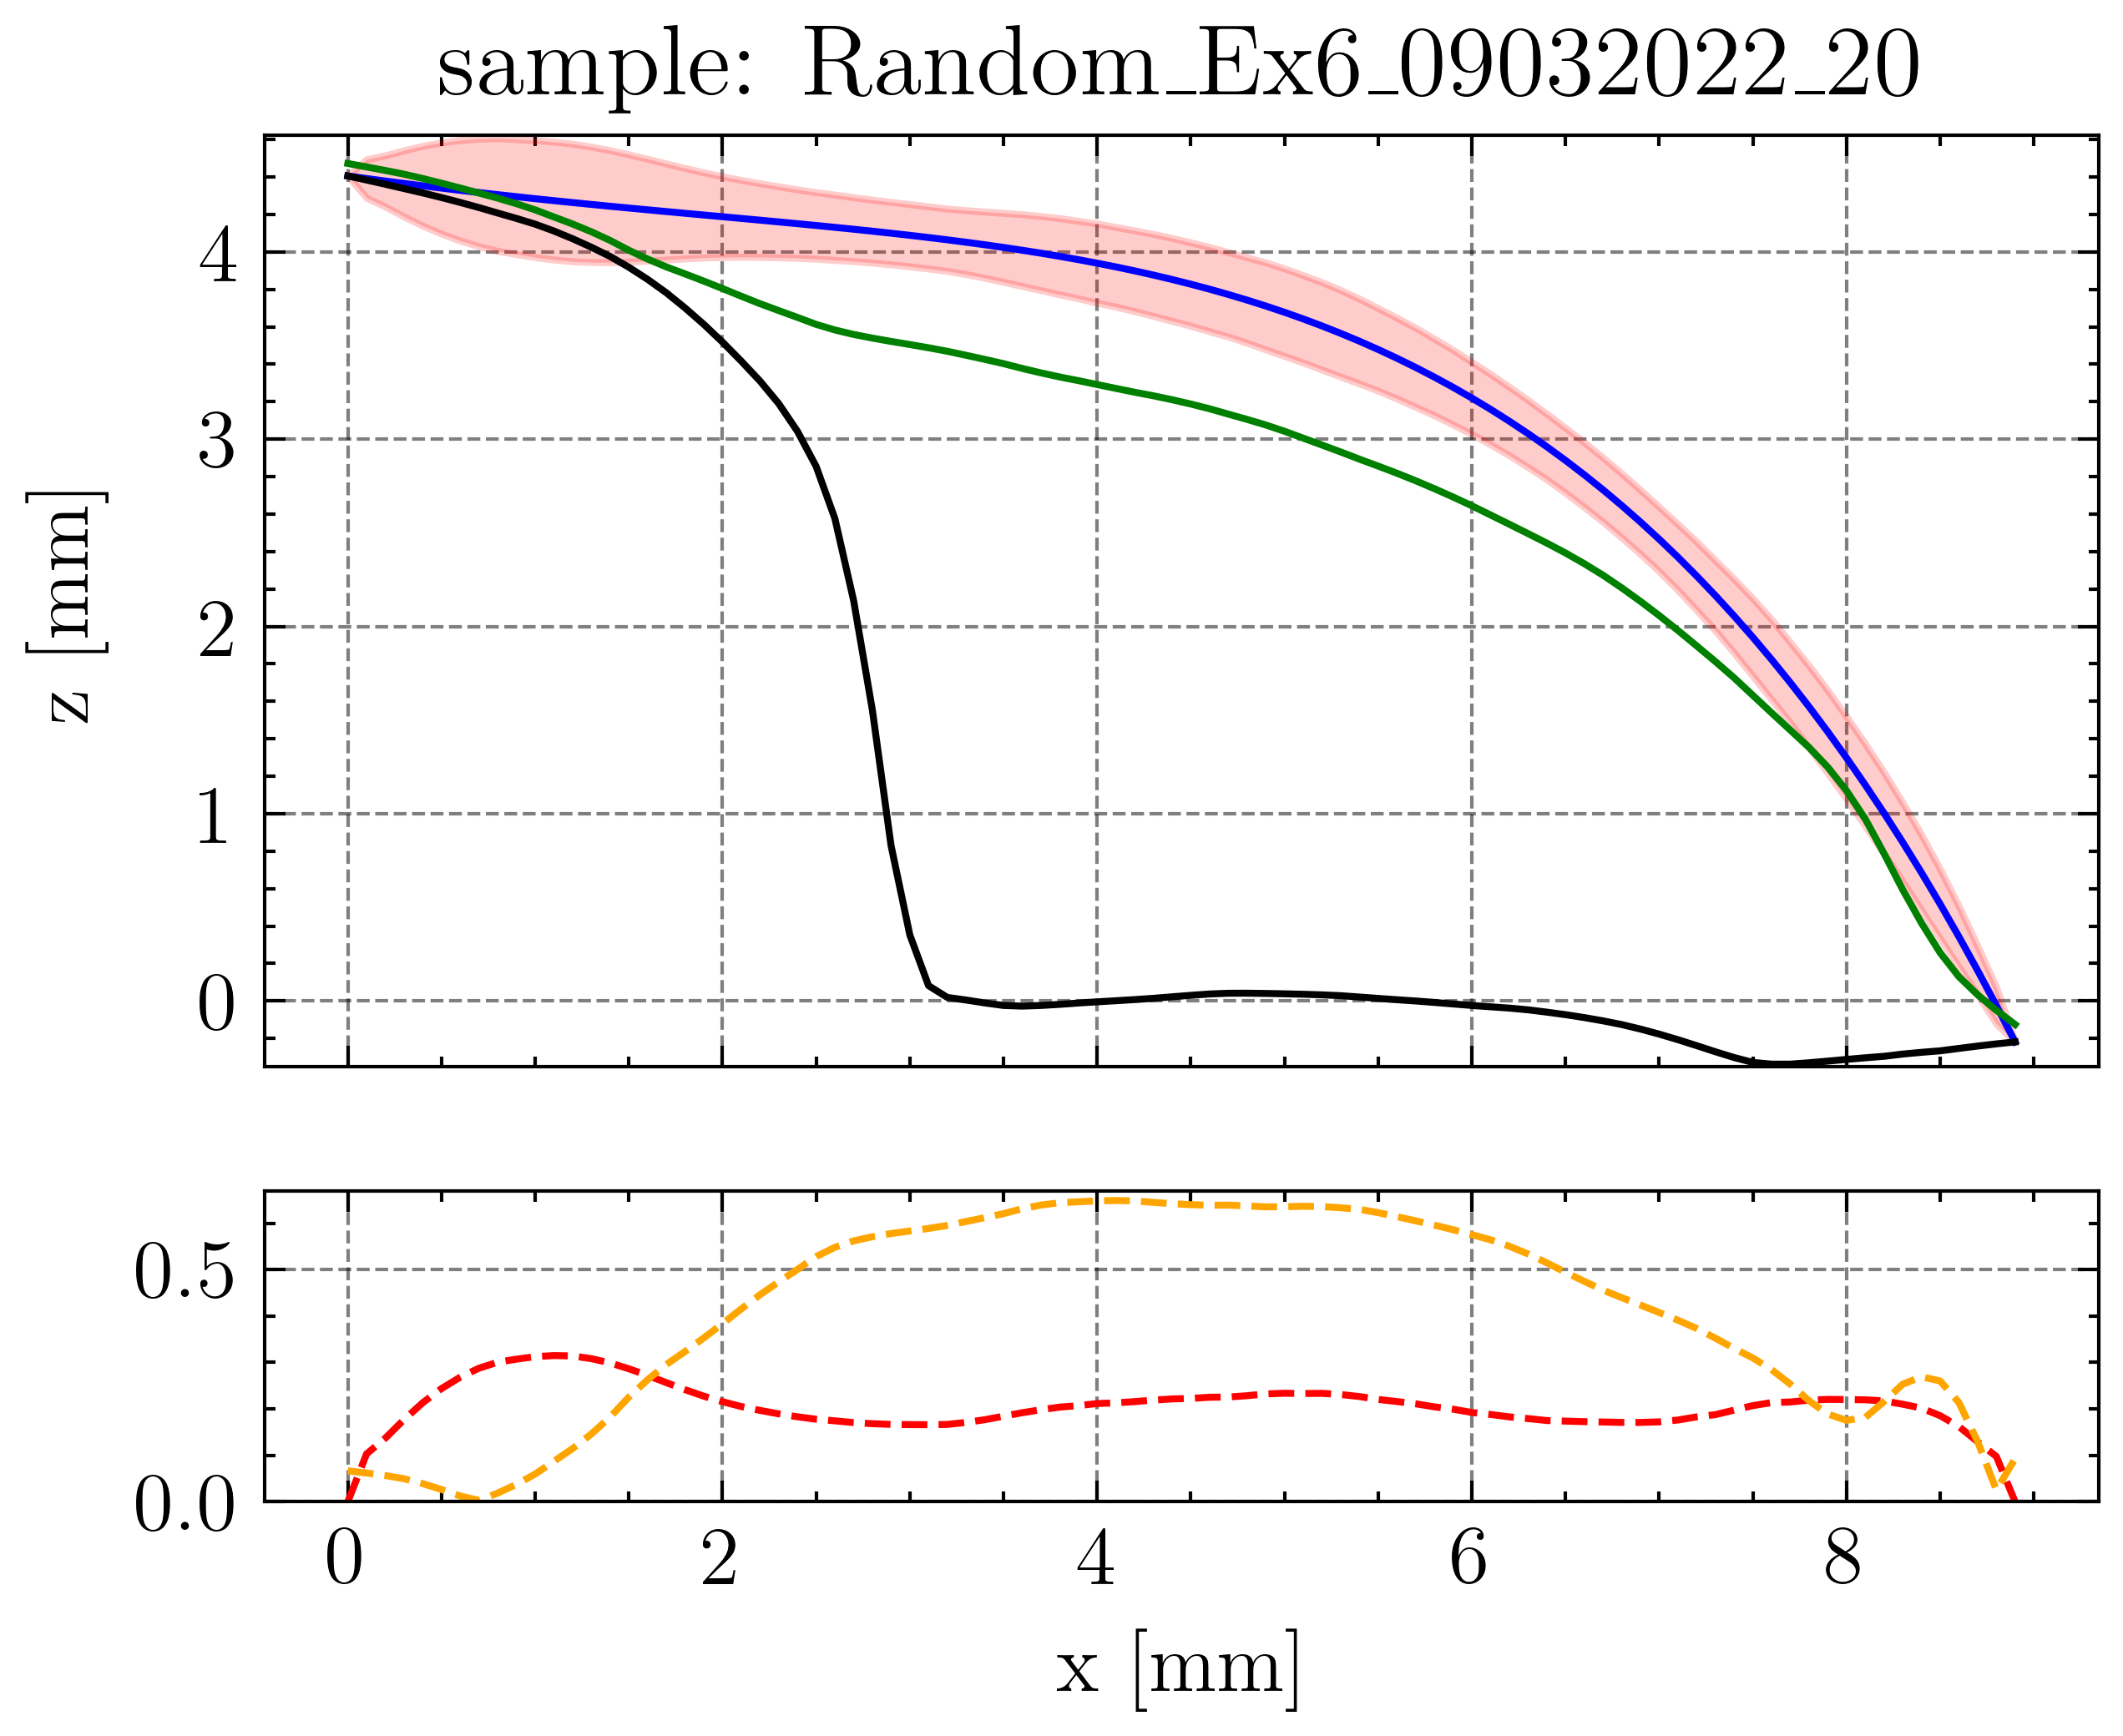

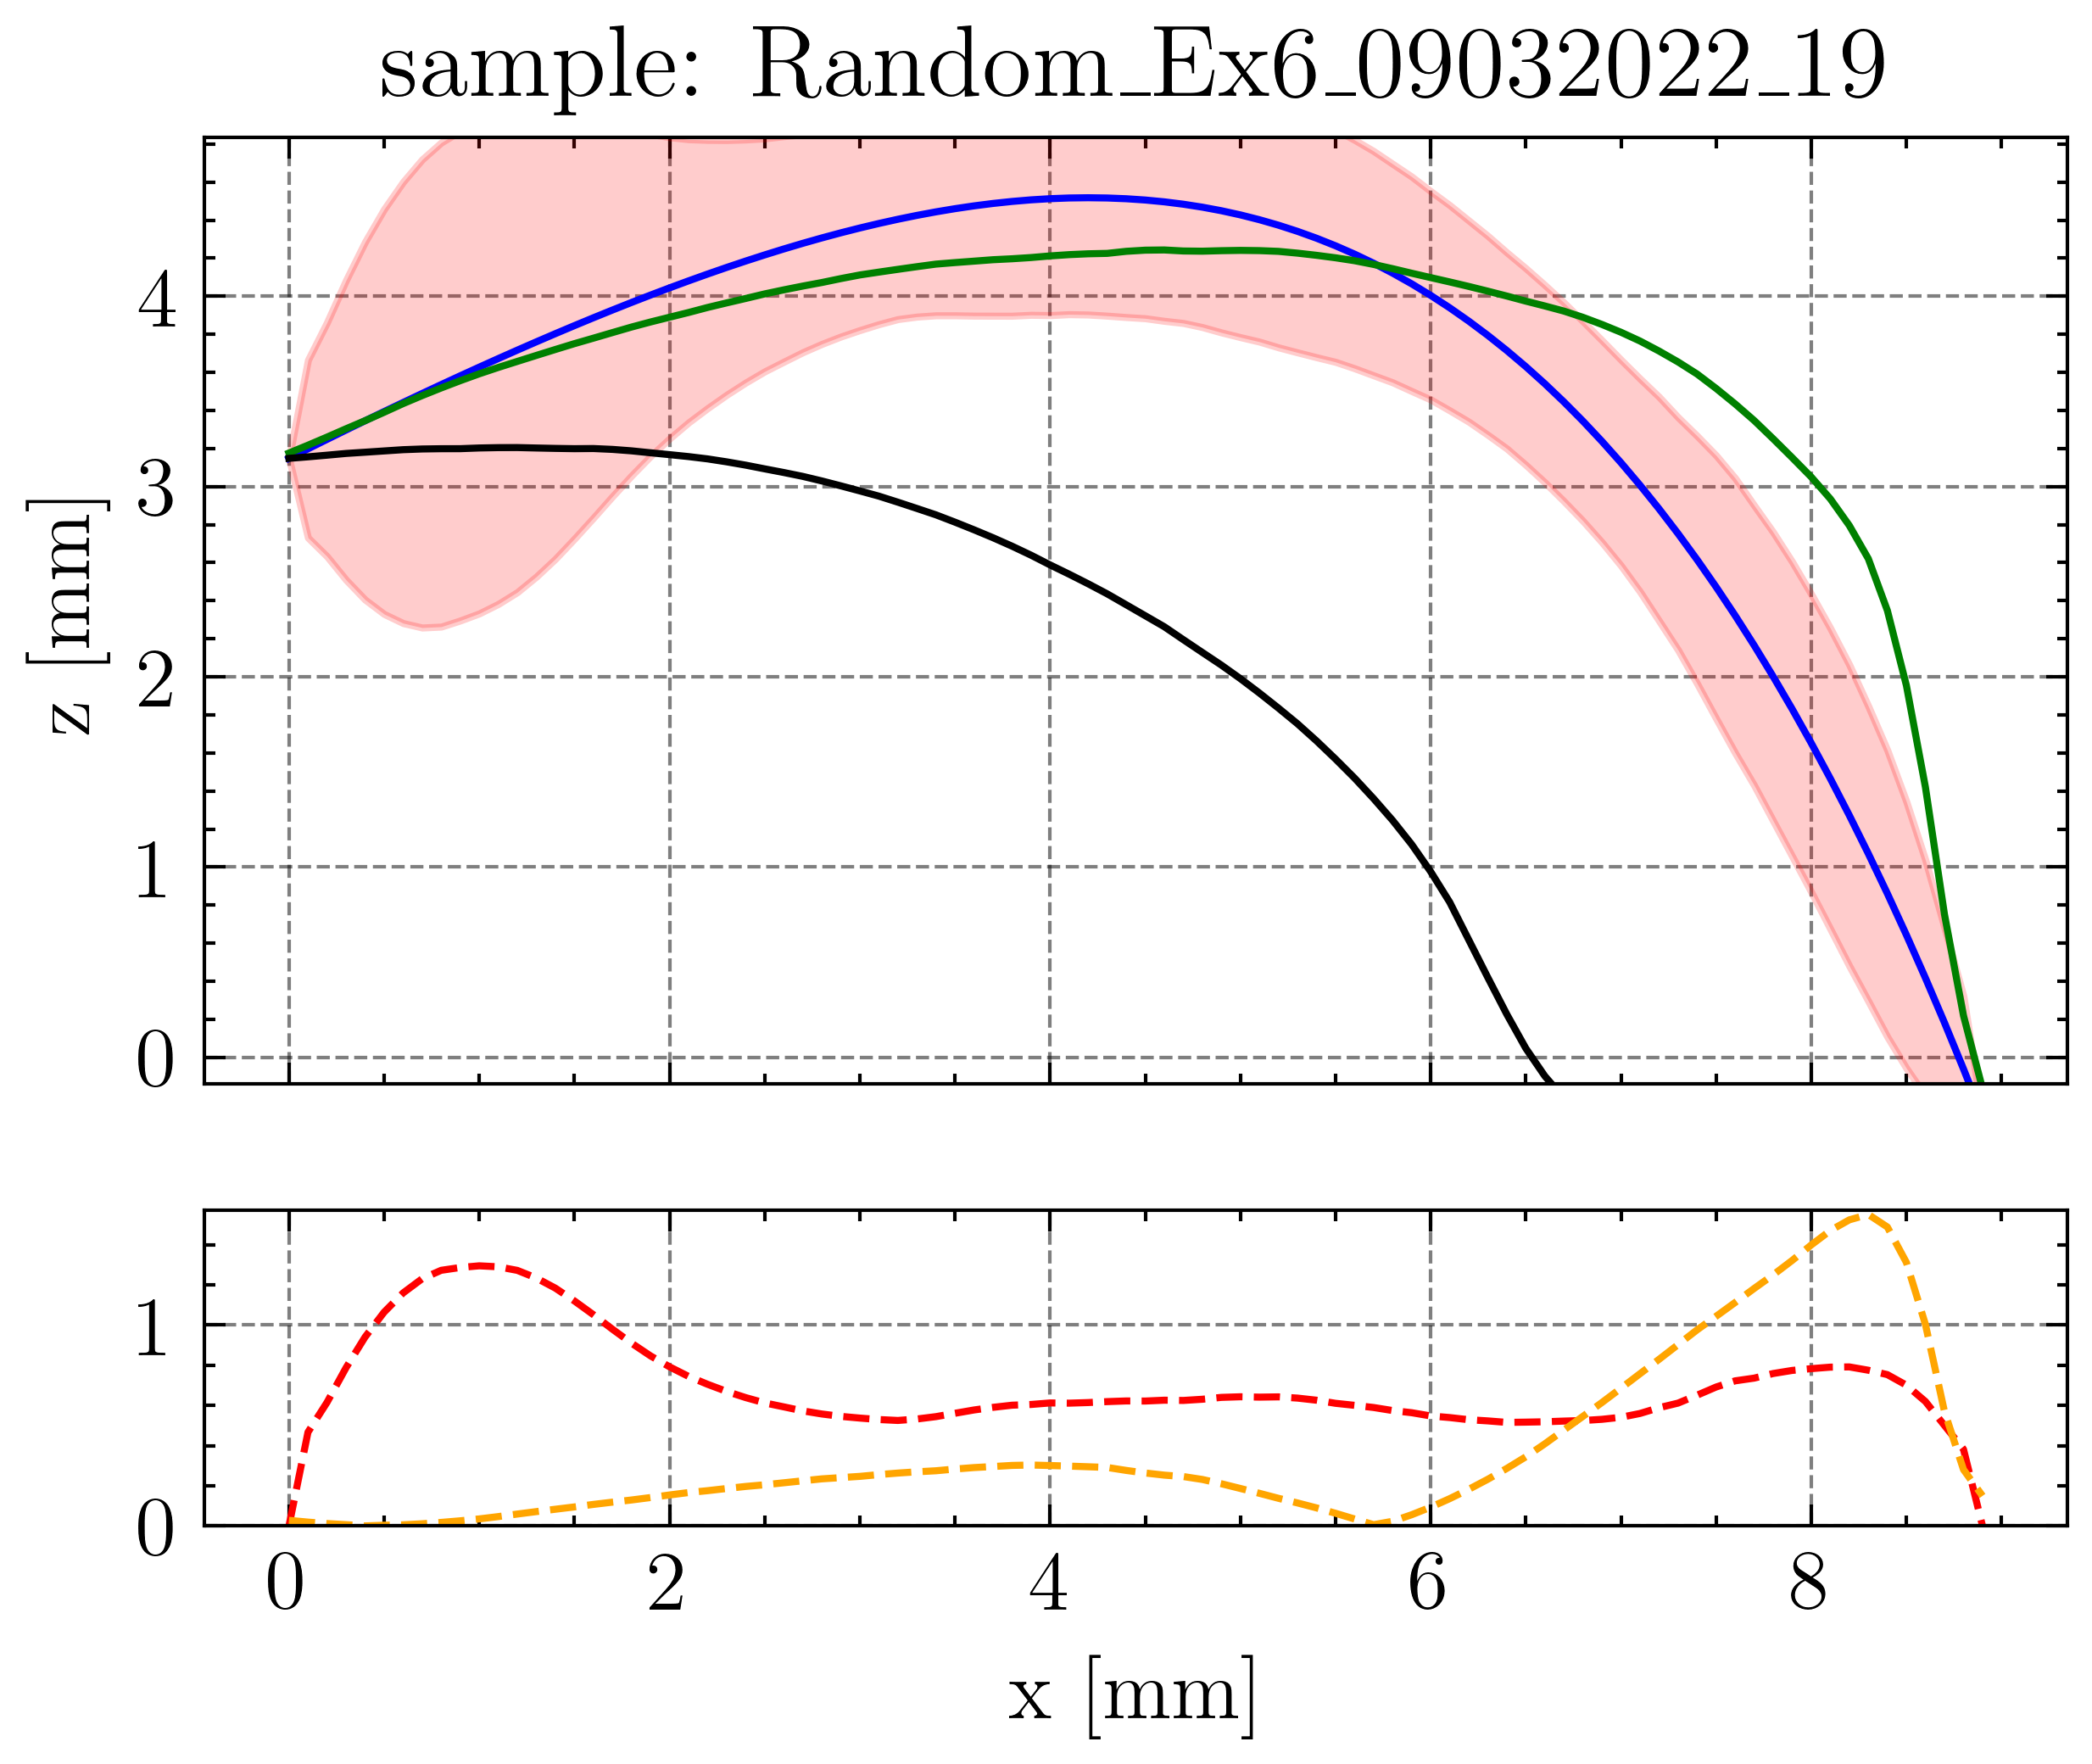

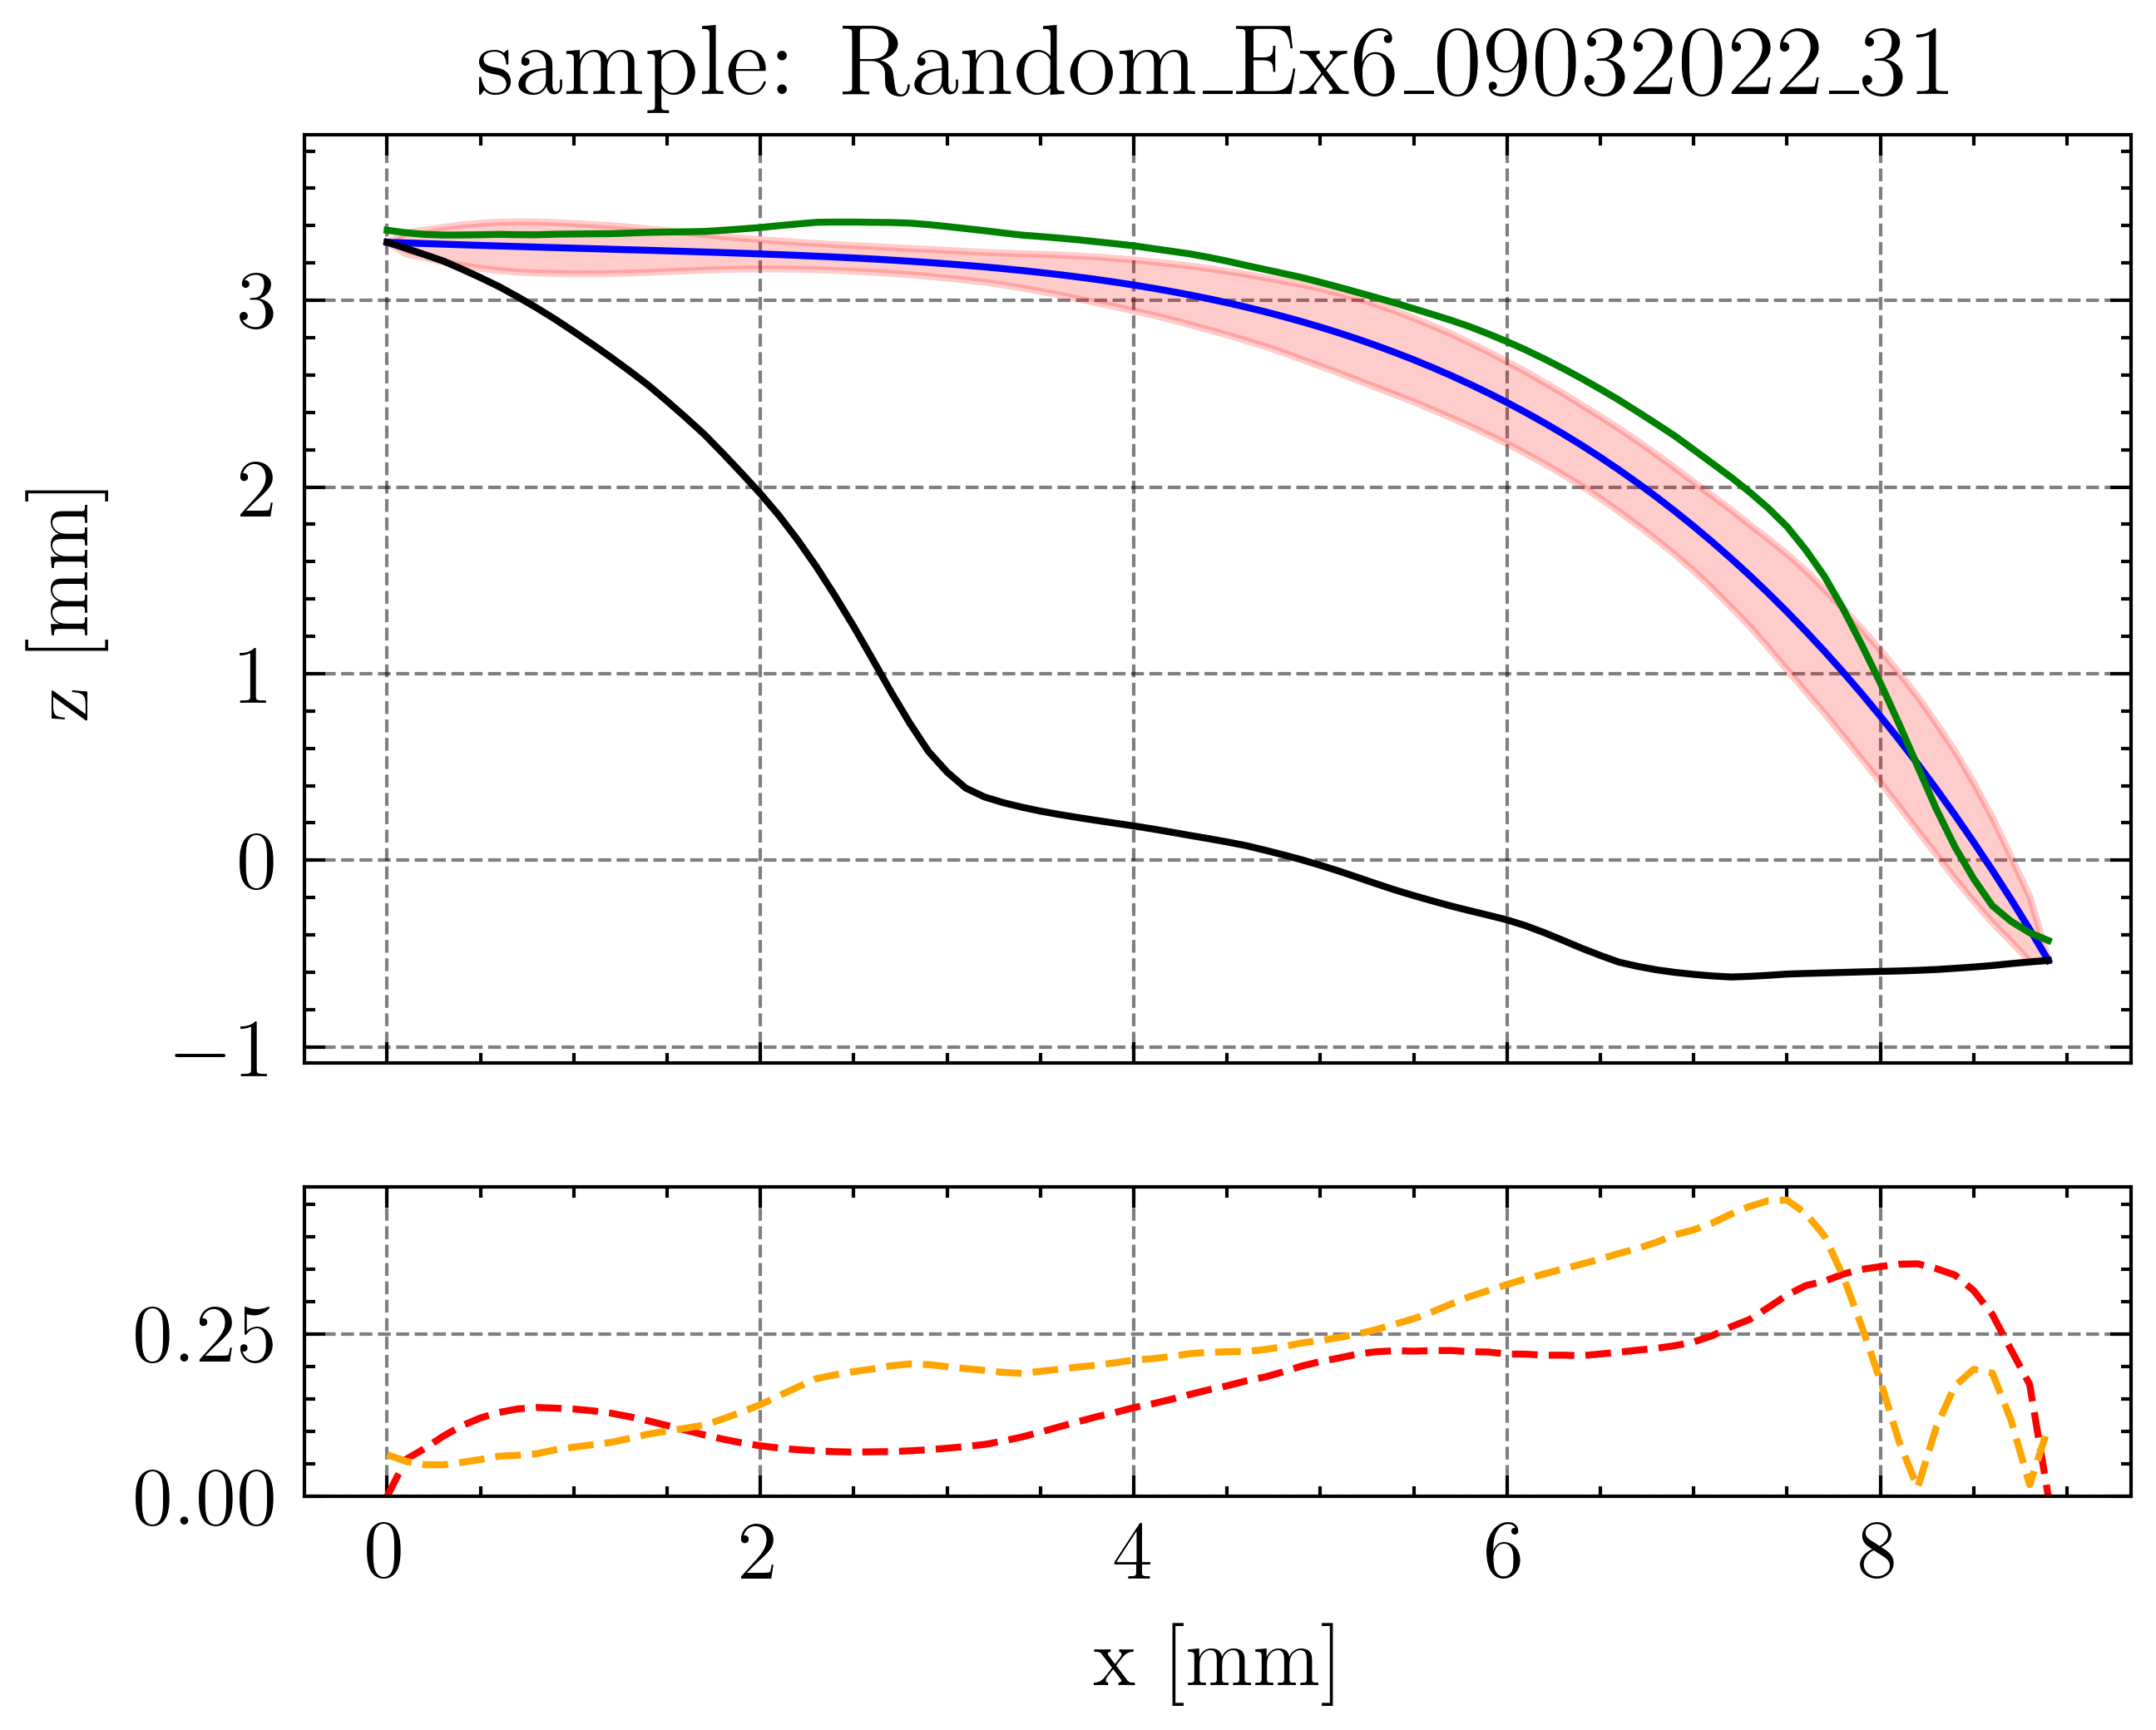

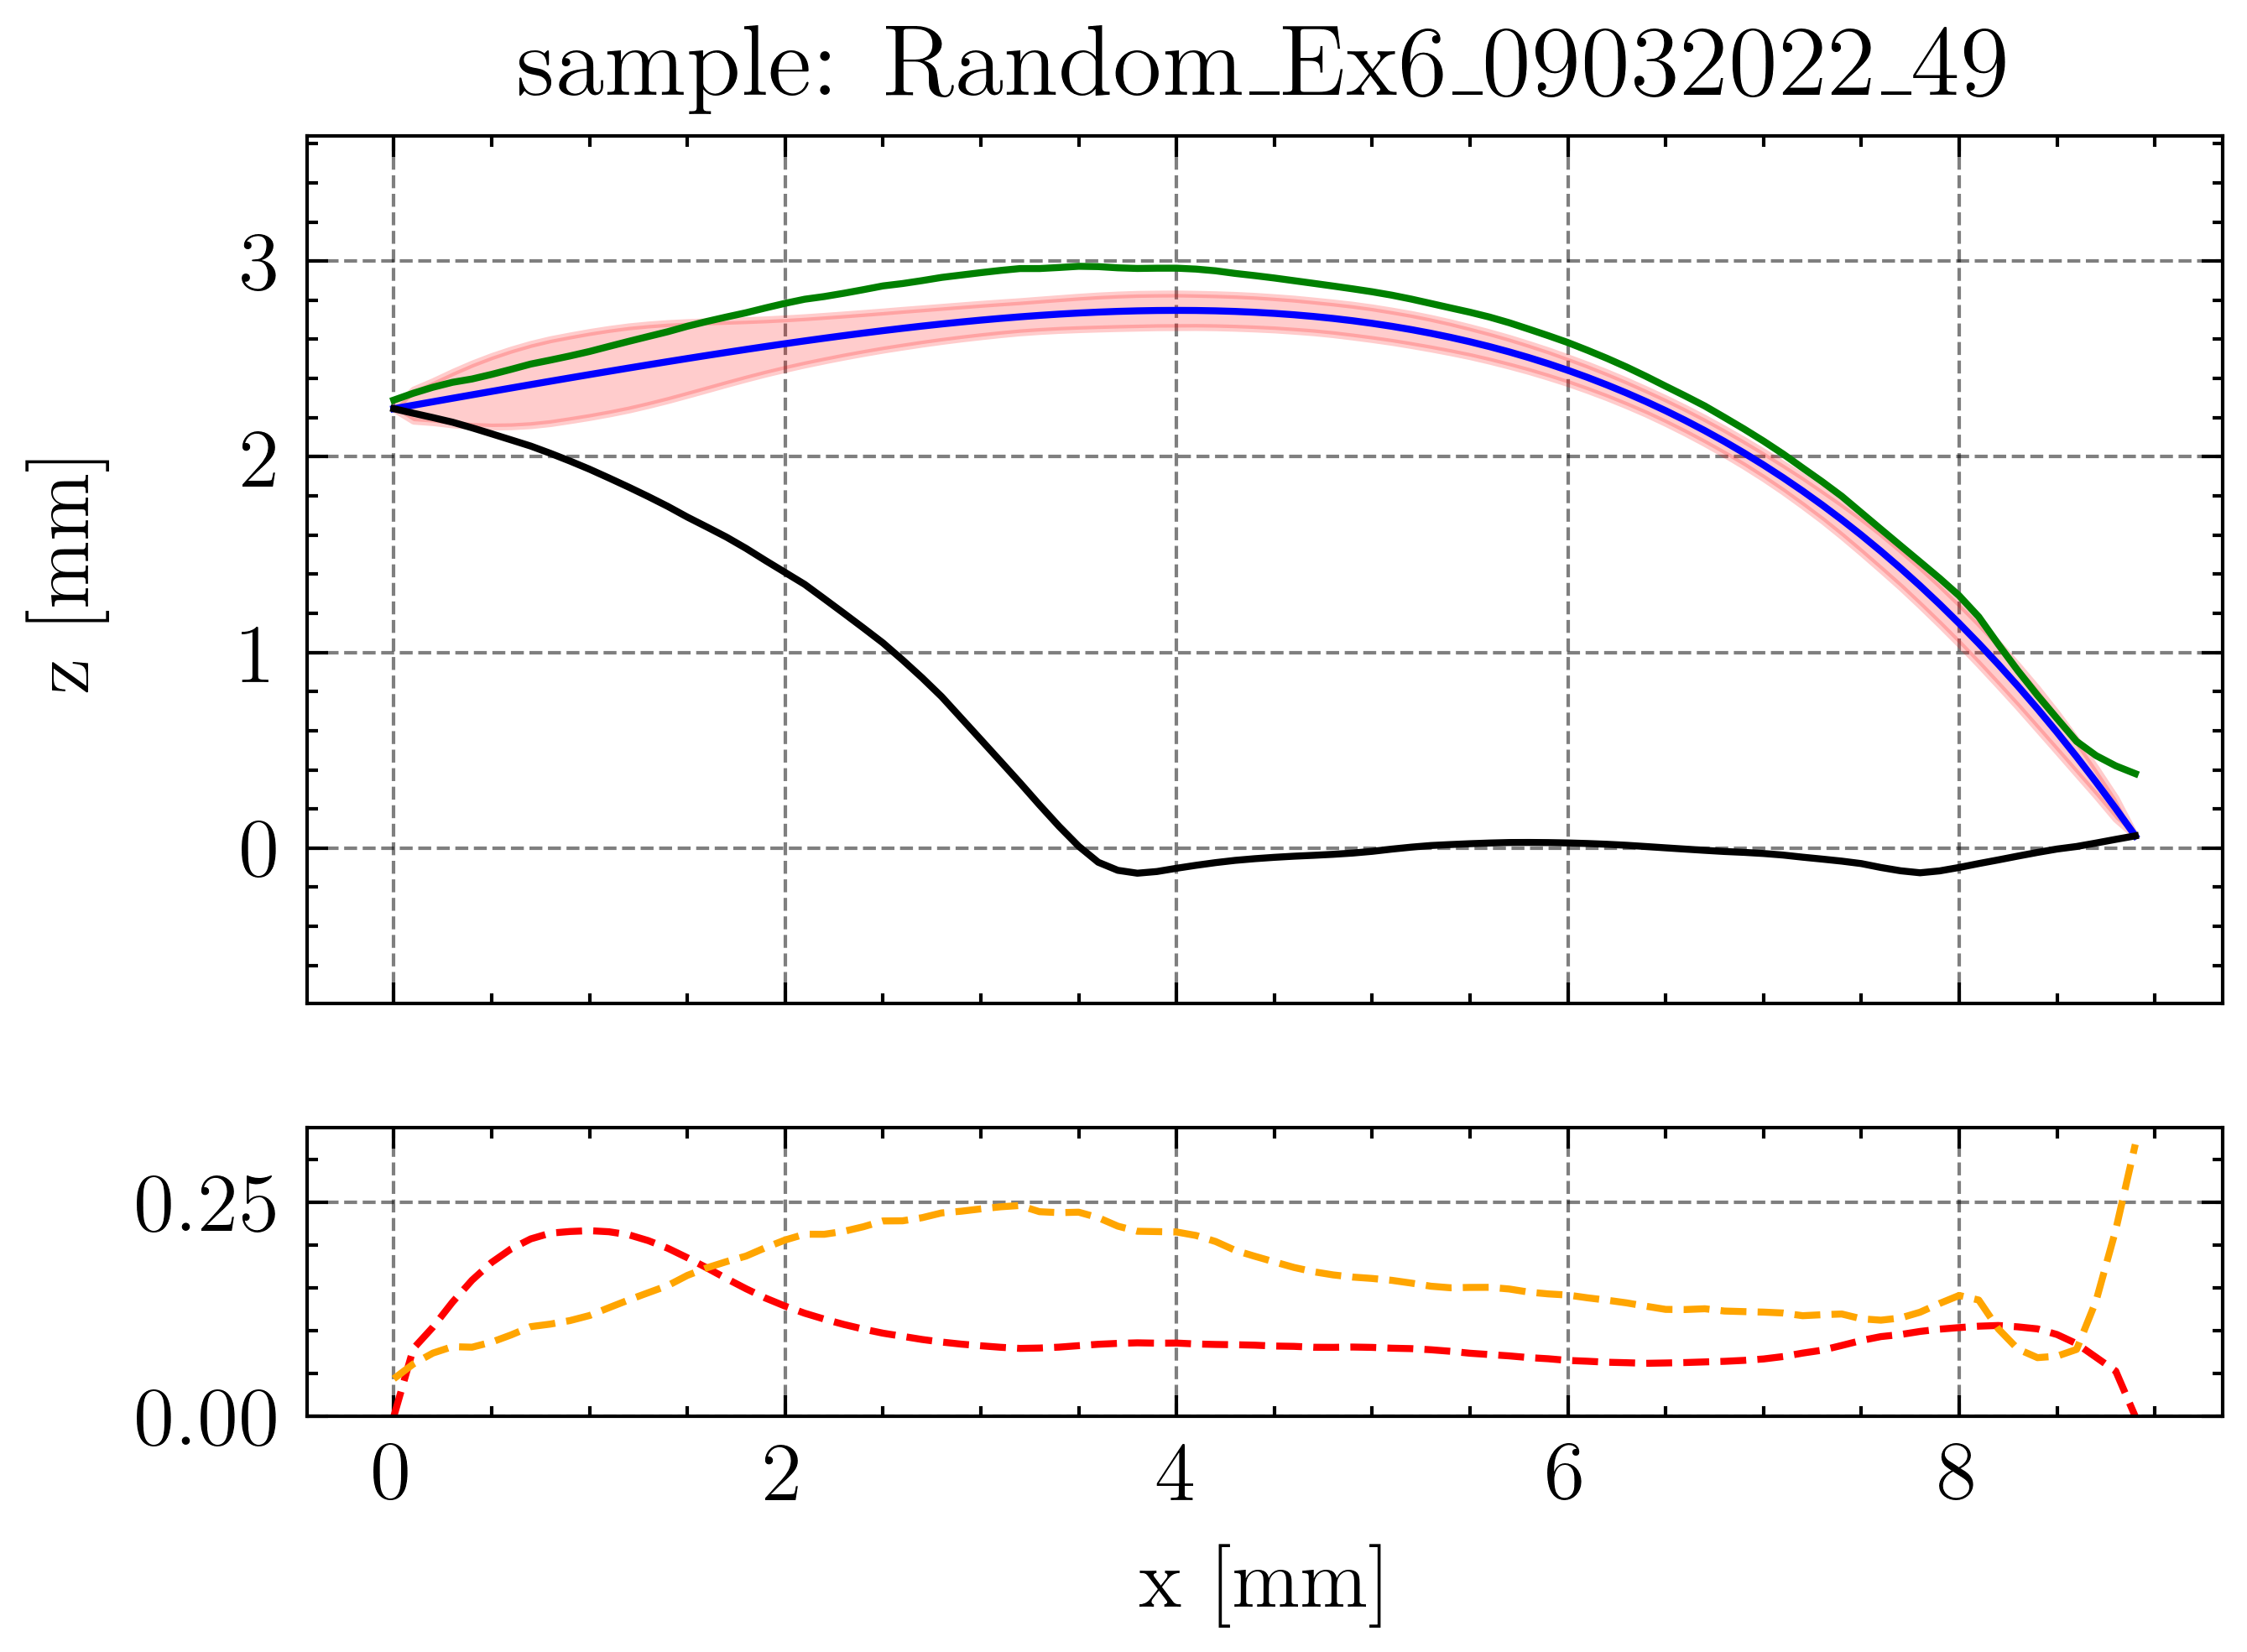

In [199]:
def fig2rgb_array(fig):
    fig.canvas.draw()
    return np.array(fig.canvas.renderer._renderer)


fig_big, axs = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={"height_ratios": [1, 1]}, sharey=False)

# Call your plotting function for each subplot
for i, ax in enumerate(axs.flatten()):
    fig = plot_sample(data.iloc[i])
    ax.axis('off')
    ax.imshow(np.zeros((1, 1)))  # Placeholder, necessary for imshow
    ax.imshow(fig2rgb_array(fig))

# Adjust layout to prevent clipping of subplot titles or labels
plt.tight_layout()

# Show the larger figure

In [302]:
scores = []
scores_max = []
hausdorff = []

for i in range(56):
    # fig = plot_sample(data.iloc[i])
    score = np.array(data.iloc[i]["uncertainties"]).sum() * 0.1
    score_max = np.array(data.iloc[i]["uncertainties"]).max()
    scores_max.append(score_max)
    scores.append(score)
    
    hausdorff.append(data.iloc[i]["modhaussdorff"])
    
    # fname = Path(f"sample_{data.iloc[i]['ids']}({i+1})_hausdorff-{data.iloc[i]['modhaussdorff']:.3f}_score-{score:.3f}.pdf")
    # fig.savefig(desktop / folder / fname, bbox_inches='tight')

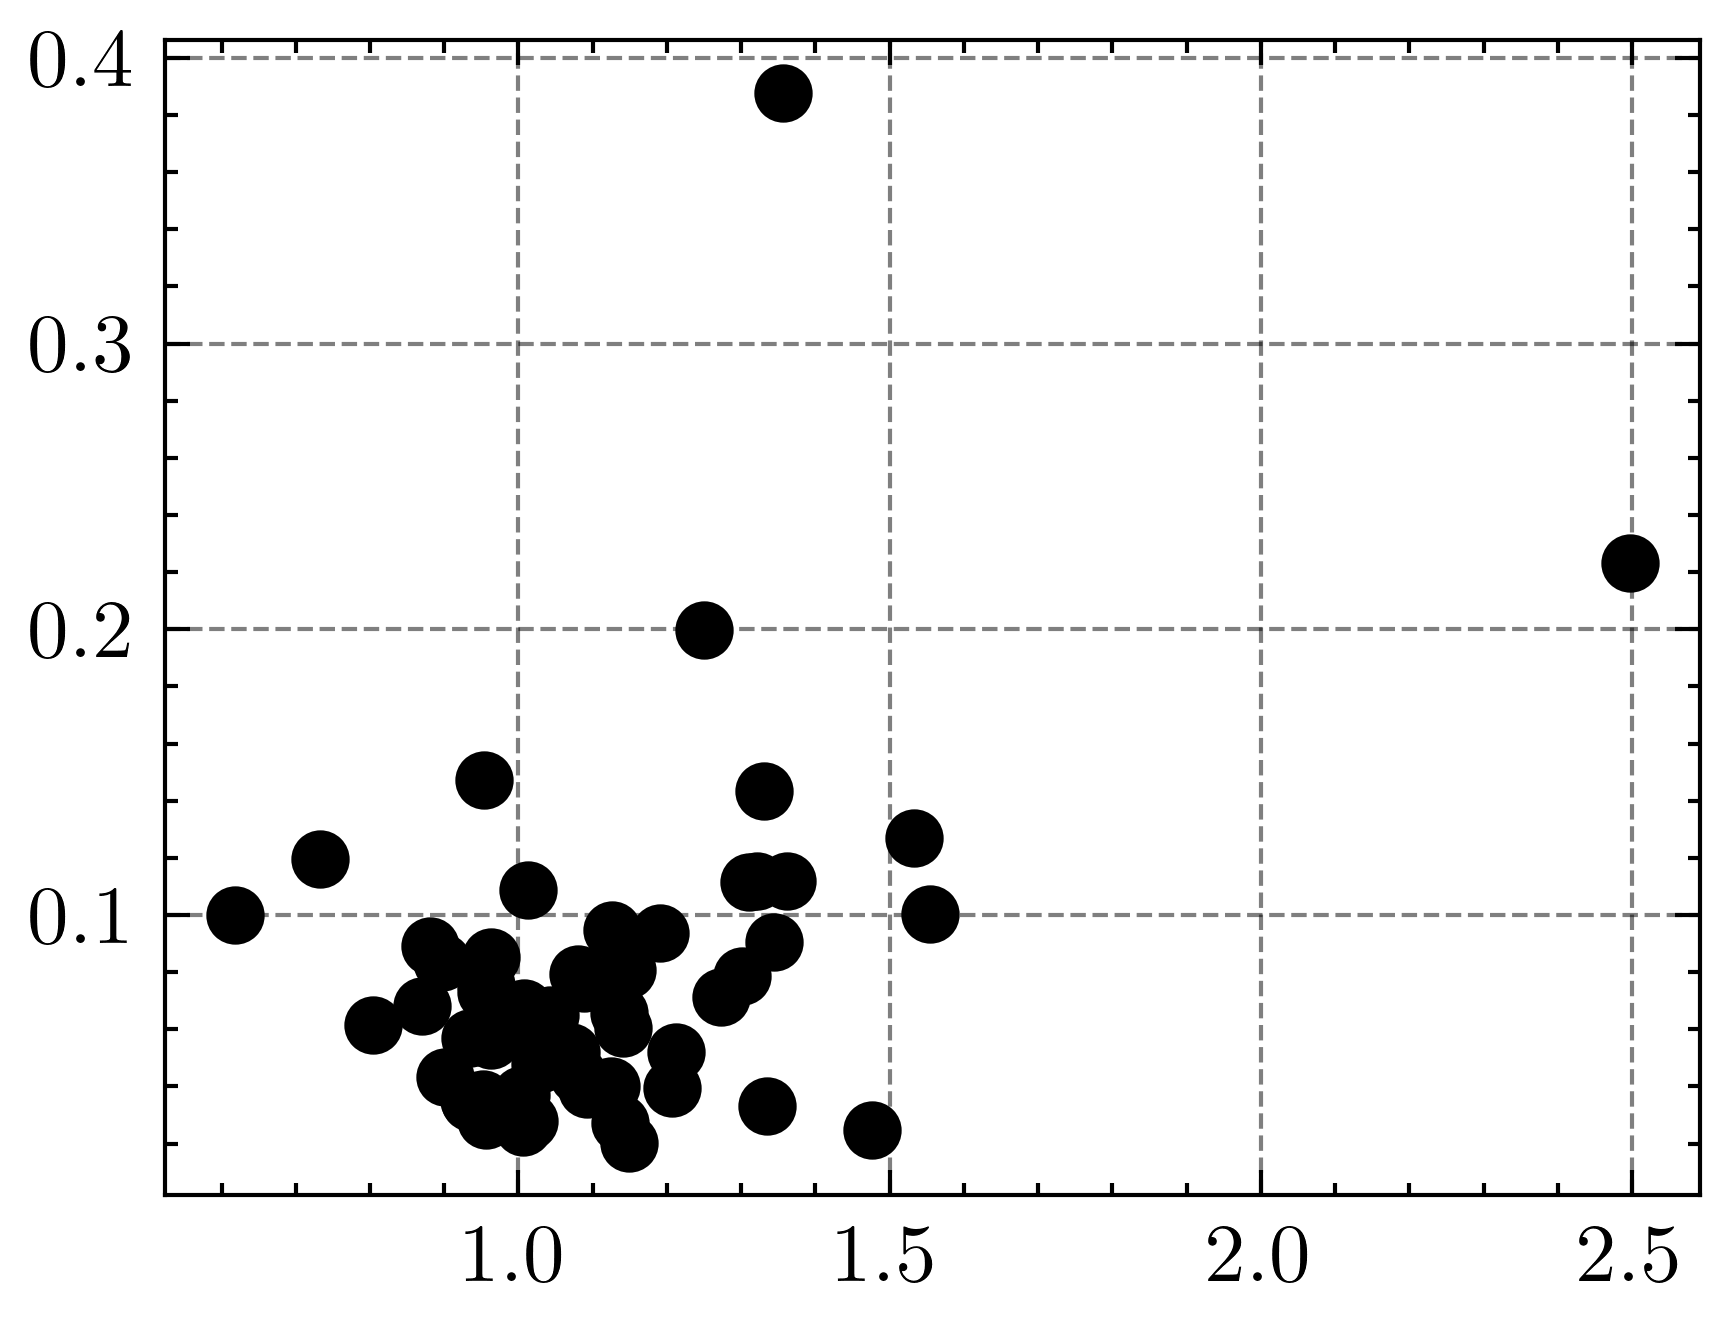

In [307]:


plt.scatter(np.sqrt(scores), hausdorff)

In [313]:
np.corrcoef(scores, hausdorff)

array([[1.        , 0.42815718],
       [0.42815718, 1.        ]])